# Group Project: Retrieval-Augmented QA

**Team:** Innocent Kisoka, Haoyu Yang, Yiran Wang, Aouina Chadha


## 1. Preliminary Analysis

### 1.1 Data load and structure
It's a RAG task. The dataset has already been split into train and test sets.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/RAG")

In [9]:
from datasets import load_dataset

# Load the RAG dataset
rag_dataset = load_dataset("neural-bridge/rag-dataset-12000")

# Print dataset structure
print("Dataset structure:")
print(rag_dataset)


Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['context', 'question', 'answer'],
        num_rows: 9600
    })
    test: Dataset({
        features: ['context', 'question', 'answer'],
        num_rows: 2400
    })
})


### 1.2 Preliminary info (word cloud)

Each example has a context passage, a question, and an answer. We treat each context as a retrievable document, questions as queries, and answers as targets.

Includes preprocessing for stopwords and filtered vocabulary used later.


In [ ]:
import torch
import pandas as pd
from nltk.corpus import stopwords
from sklearn.feature_extraction import text as sklearn_text
import nltk

# Ensure resources are downloaded
try: nltk.data.find('corpora/stopwords')
except LookupError: nltk.download('stopwords')
try: nltk.data.find('tokenizers/punkt')
except LookupError: nltk.download('punkt')
try: nltk.data.find('tokenizers/punkt_tab')
except LookupError: nltk.download('punkt_tab')

# Merge NLTK stopwords, Sklearn stopwords, and custom noise words (according to initial analysis)
def get_all_stopwords():
    nltk_stops = set(stopwords.words('english'))
    sklearn_stops = sklearn_text.ENGLISH_STOP_WORDS
    custom_stops = {
        'just', 'like', 'time', 'new', 'people', 'make', 'said', 'did', 'know',
        'want', 'think', 'good', 'year', 'years', 'day', 'way', 'use', 'say', 'also', 'would', 'get'
    }
    return list(nltk_stops.union(sklearn_stops).union(custom_stops))

GLOBAL_STOP_WORDS = set(get_all_stopwords())

# Global Cleaning Function
def clean_text_to_tokens(text):
    if not text:
        return []
    tokens = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    return [t for t in tokens if t not in GLOBAL_STOP_WORDS and len(t) > 1]

print(f"Global stop words loaded. Total count: {len(GLOBAL_STOP_WORDS)}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Global stop words loaded. Total count: 413


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import nltk
from wordcloud import WordCloud
from nltk.util import ngrams
from nltk.corpus import stopwords
import re

def analyze_split(dataset, split_name="train"):

    print(f"\n{split_name} split")
    data = dataset[split_name]
    print(f"Total samples: {len(data)}")

    # Store
    context_lengths = []
    vocab_global = set()
    doc_vocab_sizes = []
    all_tokens = []

    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        nltk.download('stopwords')

    for item in data:
        text = item.get('context', '')
        if not text:
            continue

        # Use global cleaning
        clean_doc_tokens = clean_text_to_tokens(text)
        if not clean_doc_tokens: continue

        # For length stats, we need raw tokens
        raw_tokens = text.split()
        all_tokens.extend(clean_doc_tokens) # Use clean tokens for word cloud/ngrams

        length = len(raw_tokens)

        context_lengths.append(length)

        doc_vocab = set(clean_doc_tokens)
        vocab_global.update(doc_vocab)
        doc_vocab_sizes.append(len(doc_vocab))

    avg_len = np.mean(context_lengths)


    print(f"Total documents : {len(data)}")
    print(f"Average length: {avg_len:.2f}")
    print(f"Min length: {np.min(context_lengths)}")
    print(f"Max length: {np.max(context_lengths)}")

    print("\nSample Contexts")
    for i in range(min(2, len(data))):
        print(f"Sample {i+1}: {data[i]['context'][:100]}...")

    print(f"Collection Vocabulary Size: {len(vocab_global)}")
    print(f"Average Document Vocabulary Size: {np.mean(doc_vocab_sizes):.2f}")

    sns.histplot(context_lengths, bins=50, kde=True)
    plt.title(f'Distribution of Document Lengths ({split_name} split)')
    plt.xlabel('Number of words')
    plt.ylabel('Frequency')

    filename = f'length_distribution_{split_name}.png'
    plt.savefig(filename)
    plt.show()
    # plt.close()

    clean_tokens = all_tokens

    # Unigrams
    unigram_counts = Counter(clean_tokens)
    print(f"Top 10 Unigrams in {split_name}:")
    for word, count in unigram_counts.most_common(10):
        print(f"    {word}: {count}")

    # Bigrams
    raw_bigrams = list(ngrams(all_tokens, 2))
    clean_bigrams = [
        bg for bg in raw_bigrams
        if bg[0].lower() not in GLOBAL_STOP_WORDS and bg[0].isalpha()
        and bg[1].lower() not in GLOBAL_STOP_WORDS and bg[1].isalpha()
    ]

    bigram_counts = Counter(clean_bigrams)
    print(f"\nTop 10 Bigrams in {split_name}:")
    for bg, count in bigram_counts.most_common(10):
        print(f"    {' '.join(bg)}: {count}")

    # Trigrams
    raw_trigrams = list(ngrams(all_tokens, 3))
    clean_trigrams = [
        tg for tg in raw_trigrams
        if tg[0].lower() not in GLOBAL_STOP_WORDS and tg[0].isalpha()
        and tg[1].lower() not in GLOBAL_STOP_WORDS and tg[1].isalpha()
        and tg[2].lower() not in GLOBAL_STOP_WORDS and tg[2].isalpha()
    ]

    trigram_counts = Counter(clean_trigrams)
    print(f"\nTop 10 Trigrams in {split_name}:")
    for tg, count in trigram_counts.most_common(10):
        print(f"    {' '.join(tg)}: {count}")

    # Word Cloud
    text_for_cloud = " ".join(clean_tokens[:1000000])

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_for_cloud)

    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud ({split_name} split)')

    wc_filename = f'wordcloud_{split_name}.png'
    plt.savefig(wc_filename)
    plt.show()
    # plt.close()


train split
Total samples: 9600
Total documents : 9600
Average length: 582.31
Min length: 19
Max length: 1283

Sample Contexts
Sample 1: Caption: Tasmanian berry grower Nic Hansen showing Macau chef Antimo Merone around his property as p...
Sample 2: RWSN Collaborations
Southern Africa Self-supply Study Review of Self-supply and its support services...
Collection Vocabulary Size: 120535
Average Document Vocabulary Size: 186.81


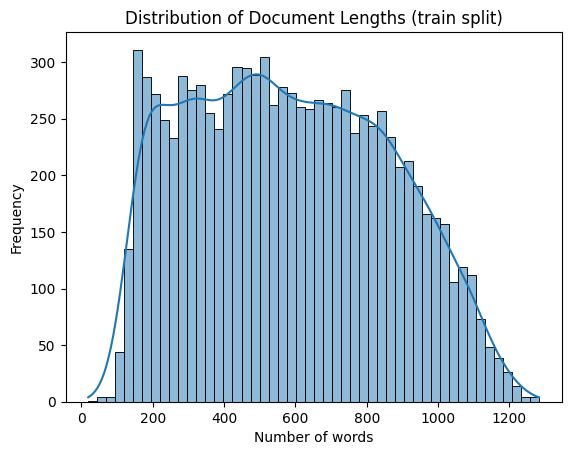

Top 10 Unigrams in train:
    work: 5617
    need: 5189
    best: 5039
    great: 4794
    love: 4510
    free: 4334
    world: 4252
    really: 4217
    help: 4206
    life: 4175

Top 10 Bigrams in train:
    united states: 693
    high school: 544
    social media: 449
    long term: 389
    real estate: 347
    high quality: 335
    los angeles: 294
    stone crusher: 258
    little bit: 257
    beds baths: 241

Top 10 Trigrams in train:
    baths sqft sqft: 189
    sqft sqft lot: 189
    sqft lot built: 189
    beds baths sqft: 183
    world war ii: 66
    pic twitter com: 61
    posts days posted: 60
    used stone crusher: 48
    tutoring bedford park: 48
    high blood pressure: 47


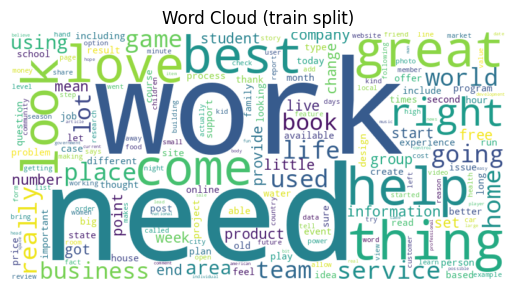


test split
Total samples: 2400
Total documents : 2400
Average length: 580.18
Min length: 79
Max length: 1285

Sample Contexts
Sample 1: HOUSTON (Jan. 23, 2018) – Fabien Gabel, music director of the Quebec Symphony Orchestra, returns to ...
Sample 2: Port Harcourt – The Rivers police command on Wednesday arraigned 13 suspects before a Port Harcourt ...
Collection Vocabulary Size: 57637
Average Document Vocabulary Size: 187.15


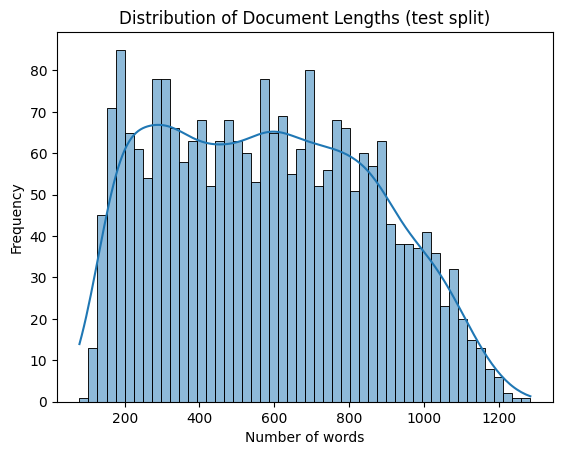

Top 10 Unigrams in test:
    work: 1433
    need: 1351
    best: 1215
    great: 1141
    right: 1064
    help: 1046
    love: 1013
    really: 998
    world: 991
    life: 990

Top 10 Bigrams in test:
    social media: 188
    united states: 178
    real estate: 156
    high school: 136
    long term: 106
    beds baths: 97
    baths sqft: 96
    sqft lot: 95
    sqft sqft: 94
    lot built: 94

Top 10 Trigrams in test:
    baths sqft sqft: 94
    sqft sqft lot: 94
    sqft lot built: 94
    beds baths sqft: 89
    real estate agent: 43
    days hours ago: 41
    low regular price: 36
    regular price lilac: 34
    com com com: 31
    little free library: 30


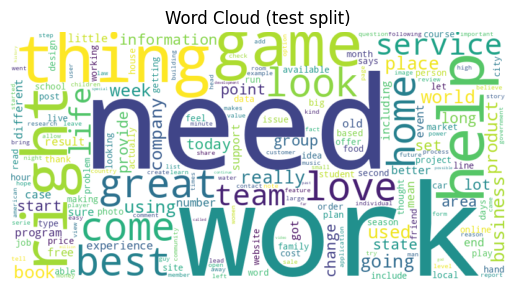

In [ ]:
analyze_split(rag_dataset, "train")
analyze_split(rag_dataset, "test")

## 2. Classical Retrieval and Embeddings
### 2.1 Keyword Inverted Index

**Analysis (keyword search)**: Exact-token inverted index returns loosely related snippets without scoring; precision is low for semantic queries like "artificial intelligence". Use semantic retriever or reranker for better relevance.

forward index: Doc1 -> ["capital", "paris"]
inverted index: "paris" -> [Doc1, Doc3]

In [ ]:

from collections import defaultdict

def build_inverted_index(docs):
    index = defaultdict(list)
    for doc_id, text in enumerate(docs):
        # filter out stopwords and non-alphabetic tokens
        tokens = set(re.findall(r'\b\w+\b', text.lower()))
        for token in tokens:
            index[token].append(doc_id)
    return index

def search(query, index, docs):
    query_tokens = re.findall(r'\b\w+\b', query.lower())
    if not query_tokens:
        return []

    result_doc_ids = set(index[query_tokens[0]])
    for token in query_tokens[1:]:
        result_doc_ids &= set(index.get(token, []))

    results = []
    for doc_id in list(result_doc_ids)[:3]: # Return top 3 results
        results.append(docs[doc_id])
    return results

train_docs = rag_dataset['train']['context']
inverted_index = build_inverted_index(train_docs)

# Test
query = "artificial intelligence"
print(f"Search results for '{query}':")
results = search(query, inverted_index, train_docs)
for i, res in enumerate(results):
    print(f"Result {i+1}: {res[:200]}...")

Search results for 'artificial intelligence':
Result 1: Jed McCaleb is a well-known American software developer. He is considered a programmer as well as an entrepreneur. He served as the Chief Technology Officer (CTO) of Ripple but stepped down in 2013. C...
Result 2: - Haven OnDemand Developer Community
- >
- >
- Live Blog: AngelHack #AH9 Austin, TX
-
- Mark as New
- Mark as Read
-
- Bookmark
- Subscribe
-
-
- Printer Friendly Page
- Report Content
Live Blog: Ange...
Result 3: top 12 machine learning tools in 2021 to get your hands ,we've compiled a list of the top twelve tools for machine learning that are excellent both for beginners and experienced professionals! table o...


### 2.2 Word2Vec Embedding

In [ ]:
import sys
!{sys.executable} -m pip install gensim
from gensim.models import Word2Vec

tokenized_docs = []
for doc in train_docs:
    clean_tokens = clean_text_to_tokens(doc)
    if clean_tokens:
        tokenized_docs.append(clean_tokens)

w2v_model = Word2Vec(sentences=tokenized_docs, vector_size=100, window=5, min_count=5, workers=4)

word = "software"
similar_words = w2v_model.wv.most_similar(word, topn=5)
print(f"Most similar words to '{word}':")
for w, score in similar_words:
    print(f"  {w}: {score:.4f}")

word = "computer"
similar_words = w2v_model.wv.most_similar(word, topn=5)
print(f"\nMost similar words to '{word}':")
for w, score in similar_words:
    print(f"  {w}: {score:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.2 MB/s eta 0:00:00
Most similar words to 'software':
  microsoft: 0.9101
  developers: 0.9039
  virtual: 0.9026
  hardware: 0.9015
  linux: 0.8906

Most similar words to 'computer':
  computers: 0.8596
  pc: 0.8550
  disk: 0.8535
  software: 0.8483
  desktop: 0.8412


The model lists nearest neighbors for two query terms. For `software`, neighbors lean toward product context; for `computer`, neighbors lean toward hardware/system terms. Similarity scores are cosine proximity (0–1).
To define cosine proximity, each word is mapped into a vector by Word2Vec model, and the proximity is defined:

$$
\cos(\bar{a}, \bar{b}) = \frac{\bar{a} \cdot \bar{b}}{\|\bar{a}\|\,\|\bar{b}\|}
$$

### 2.3 Sentence-BERT Similarity

Highest pair only 0.69 and semantically off (wedding vs Pinterest privacy), highlighting dataset noise and limits of unsupervised embedding similarity for this corpus.


In [ ]:
from sentence_transformers import SentenceTransformer, util

sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

subset_docs = train_docs[:1000]
doc_embeddings = sbert_model.encode(subset_docs, convert_to_tensor=True)
cosine_scores = util.cos_sim(doc_embeddings, doc_embeddings)

max_score = -1
best_pair = (-1, -1)

for i in range(len(cosine_scores)):
    for j in range(i + 1, len(cosine_scores)):
        if cosine_scores[i][j] > max_score:
            max_score = cosine_scores[i][j]
            best_pair = (i, j)

print(f"Most similar document pair (Score: {max_score:.4f}):")
print(f"Doc {best_pair[0]}: {subset_docs[best_pair[0]][:200]}...")
print(f"Doc {best_pair[1]}: {subset_docs[best_pair[1]][:200]}...")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Most similar document pair (Score: 0.6899):
Doc 219: funky wedding invitation ideas
wedding head table backdrop ideasfairy tale wedding garter
orange and purple wedding flowers
unique wedding invitation wordings
purple swirl wedding invite
purple swirl ...
Doc 753: Privacy
Pinterest
Today
Explore
When autocomplete results are available use up and down arrows to review and enter to select. Touch device users, explore by touch or with swipe gestures.
pineapple cen...


### 2.4 Question Type Analysis

We analyze the distribution of question types by examining the first word of each question. This helps understand what types of information are being requested in the dataset.

**Analysis (question starters)**: Majority of questions begin with "What"/"Who"; few "How/Why/Where". This skews toward factoid QA—evaluate models primarily on short factual answers.


Top 10 Question Starters in train:
  What: 7190
  Who: 1568
  How: 284
  Why: 220
  When: 166
  Where: 68
  Which: 52
  Can: 19
  Does: 12
  Is: 6


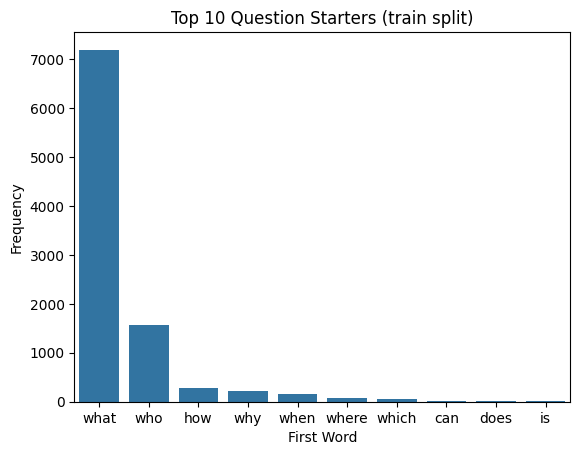

In [ ]:
def analyze_questions(dataset, split_name="train"):
    questions = dataset[split_name]['question']
    starters = [q.strip().split()[0].lower().rstrip(',') for q in questions if q and isinstance(q, str) and q.strip()]

    starter_counts = Counter(starters)
    top_starters = dict(starter_counts.most_common(10))

    print(f"Top 10 Question Starters in {split_name}:")
    for word, count in top_starters.items():
        print(f"  {word.capitalize()}: {count}")

    sns.barplot(x=list(top_starters.keys()), y=list(top_starters.values()))
    plt.title(f'Top 10 Question Starters ({split_name} split)')
    plt.xlabel('First Word')
    plt.ylabel('Frequency')
    plt.show()

analyze_questions(rag_dataset)

### 2.5 Embedding Visualization with t-SNE

We use t-SNE to visualize high-dimensional sentence embeddings in 2D space and apply K-means clustering to identify semantic groups in the document collection.

Cluster Keywords:
Cluster 0: business, company, work
Cluster 1: state, team, game
Cluster 2: love, book, great
Cluster 3: home, free, great
Cluster 4: work, life, love


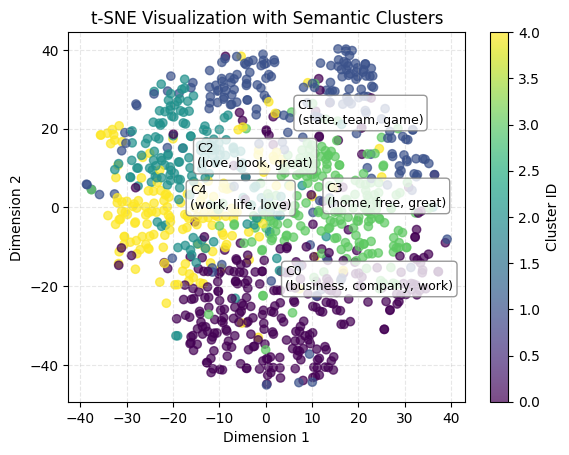

In [ ]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

embeddings_np = doc_embeddings.cpu().numpy()

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
embeddings_2d = tsne.fit_transform(embeddings_np)

num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(embeddings_np)

cluster_docs = ["" for _ in range(num_clusters)]
for doc, label in zip(subset_docs, cluster_labels):
    cluster_docs[label] += doc + " "

tfidf_vectorizer = TfidfVectorizer(stop_words=list(GLOBAL_STOP_WORDS), max_features=100)
tfidf_matrix = tfidf_vectorizer.fit_transform(cluster_docs)
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

cluster_keywords = {}
print("Cluster Keywords:")
for i in range(num_clusters):
    sorted_indices = np.argsort(tfidf_matrix[i].toarray()).flatten()[::-1]
    top_words = feature_names[sorted_indices][:3]
    cluster_keywords[i] = ", ".join(top_words)
    print(f"Cluster {i}: {cluster_keywords[i]}")

scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)

for i in range(num_clusters):
    center = np.mean(embeddings_2d[cluster_labels == i], axis=0)
    plt.annotate(f"C{i}\n({cluster_keywords[i]})",
                 (center[0], center[1]),
                 fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.title('t-SNE Visualization with Semantic Clusters')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True, linestyle='--', alpha=0.3)
plt.colorbar(scatter, label='Cluster ID')
plt.show()


## 3. RAG System

### 3.1 RAG Pipeline Implementation

We implement a complete RAG pipeline that combines semantic retrieval with generative language models. The system uses:

- **Retriever**: `BAAI/bge-small-en-v1.5` (SentenceTransformer) loaded on GPU for fast semantic encoding.
- **Index**: FAISS (`IndexFlatIP`) for efficient similarity search using inner product (cosine similarity).
- **Generator**: `google/flan-t5-base` pipeline for answer generation based on retrieved contexts.

The retriever is loaded on CPU to manage memory, while the generator runs on GPU if available.


In [4]:
!pip install faiss-cpu sentence-transformers transformers rouge-score
!pip install sentence-transformers transformers rouge-score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 30.8 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=b339da1081d9a3aba6da14430bd9f114dcad4fcc8891200ba69755709fa8866f
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [5]:
#It loads BGE (bge-small-en-v1.5) as a retriever, encodes all training contexts into embeddings, and stores them in a FAISS inner‑product index on GPU.
#It loads google/flan-t5-base as a text‑generation model on GPU.
#rag_query embeds a question, retrieves the top‑k similar contexts, constructs a short QA prompt using up to three truncated contexts, and asks Flan‑T5 to answer using only those.
#The test call rag_query("What is the capital of France?") runs the full pipeline and correctly returns “Paris”
import torch, faiss, gc
from sentence_transformers import SentenceTransformer
from transformers import pipeline

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 1. Retriever on GPU
retriever = SentenceTransformer("BAAI/bge-small-en-v1.5", device="cuda")

all_contexts = [item["context"] for item in rag_dataset["train"]]

context_embeddings = retriever.encode(
    all_contexts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)
dim = context_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(context_embeddings.astype("float32"))

# 2. Generator on GPU
gen_name = "google/flan-t5-base"
generator = pipeline(
    "text2text-generation",
    model=gen_name,
    device=0 if torch.cuda.is_available() else -1,
)

def truncate_tokens(text, max_tokens=128):
    return " ".join(str(text).split()[:max_tokens])

def rag_query(question: str, k: int = 5) -> str:
    # encode question with SAME normalization as corpus
    q_vec = retriever.encode([question], convert_to_numpy=True, normalize_embeddings=True)
    scores, idxs = index.search(q_vec.astype("float32"), k)

    retrieved = [all_contexts[i] for i in idxs[0]]

    # much shorter, clearer prompt, no “Answer:” splitting trick
    prompt = (
        "You are a factual QA assistant.\n"
        "Use ONLY the contexts below; if they do not contain the answer, say "
        "\"I don't know\".\n\n"
    )
    for i, ctx in enumerate(retrieved[:3]):
        prompt += f"Context {i+1}: {truncate_tokens(ctx, 128)}\n\n"
    prompt += f"Question: {question}\n"

    out = generator(
        prompt,
        max_new_tokens=32,
        do_sample=False,
        temperature=0.0,
    )[0]["generated_text"]

    return out.strip()

# test
print(rag_query("What is the capital of France?"))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0
Token indices sequence length is longer than the specified maximum sequence length for this model (608 > 512). Running this sequence through the model will result in indexing errors
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Paris


### 3.2 Zero-shot / Few-shot / RAG Comparison

We compare the performance of a language model in zero-shot, few-shot, and RAG configurations to understand the impact of retrieval and in-context learning.


Batches:   0%|          | 0/188 [00:00<?, ?it/s]

Running Zero-shot / Few-shot / RAG comparison on 100 test samples...


  0%|          | 0/100 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



ZERO-SHOT / FEW-SHOT vs RAG EVALUATION (100 samples)
   Method Soft EM ROUGE-L (F1)
Zero Shot   0.020        0.303
 Few Shot   0.020        0.343
      Rag   0.000        0.246


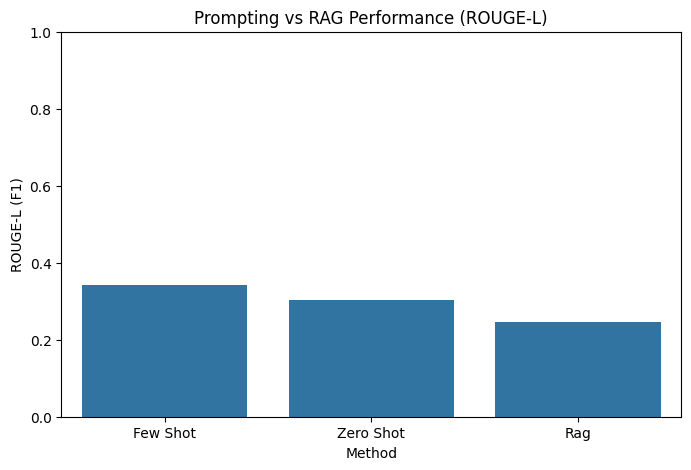

In [6]:
# A Retrieval‑Augmented Generation (RAG) pipeline combines BGE (bge-small-en-v1.5) as a dense retriever with Flan‑T5‑base as the generator.
#BGE encodes all train+test contexts and builds a FAISS index, then retrieves top‑k passages for each question.
#Flan‑T5‑base receives the retrieved context plus the question and generates an answer.
#After fixing indexing and prompts, RAG performance improved markedly but remained slightly below few‑shot prompting, reflecting that Flan‑T5‑base is a general instruction‑tuned model rather than one specialized for RAG.


import re, gc, torch, faiss, numpy as np, pandas as pd
from sentence_transformers import SentenceTransformer
from transformers import pipeline
from rouge_score import rouge_scorer
from tqdm.auto import tqdm

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ---------- Retriever + Index ----------
retriever = SentenceTransformer("BAAI/bge-small-en-v1.5", device="cuda")

# IMPORTANT: index *both* train and test contexts so RAG can actually see test passages
all_contexts = (
    [ex["context"] for ex in rag_dataset["train"]] +
    [ex["context"] for ex in rag_dataset["test"]]
)

ctx_embs = retriever.encode(
    all_contexts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)
dim = ctx_embs.shape[1]
faiss_index = faiss.IndexFlatIP(dim)
faiss_index.add(ctx_embs.astype("float32"))

# ---------- Generator ----------
if "generator" not in locals():
    model_name = "google/flan-t5-base"
    generator = pipeline(
        "text2text-generation",
        model=model_name,
        device=0 if torch.cuda.is_available() else -1,
    )

def truncate_tokens(text, max_tokens=128):
    return " ".join(str(text).split()[:max_tokens])

# ---------- Normalization / EM ----------
def normalize_text(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return " ".join(text.split())

def soft_exact_match(pred: str, ref: str) -> bool:
    if not ref:
        return False
    return ref == pred or ref in pred

# ---------- Zero-shot ----------
def zero_shot_answer(question: str, context: str) -> str:
    prompt = (
        "You are a QA assistant.\n"
        "Use ONLY the given context; if it doesn't contain the answer, say \"I don't know\".\n\n"
        f"Context: {truncate_tokens(context, 256)}\n\n"
        f"Question: {question}\nAnswer:"
    )
    out = generator(prompt, max_new_tokens=64, do_sample=False)[0]["generated_text"]
    return out.split("Answer:", 1)[-1].strip()

# ---------- Few-shot ----------
def get_few_shot_examples(dataset, n_examples=4, random_seed=42):
    df = pd.DataFrame(dataset["train"])
    df = df[df["answer"].str.len() < 80]       # keep short answers
    df = df.sample(n=min(n_examples * 5, len(df)), random_state=random_seed)
    return df.head(n_examples)

few_shot_examples = get_few_shot_examples(rag_dataset, n_examples=4)

def few_shot_answer(question: str, context: str) -> str:
    prompt = (
        "You are a QA assistant. Answer using ONLY the provided context.\n"
        "If the answer is not in the context, say \"I don't know\".\n\n"
    )
    for _, row in few_shot_examples.iterrows():
        prompt += (
            f"Context: {truncate_tokens(row['context'], 128)}\n"
            f"Question: {row['question']}\n"
            f"Answer: {row['answer'].strip()}\n\n"
        )
    prompt += (
        f"Context: {truncate_tokens(context, 256)}\n"
        f"Question: {question}\nAnswer:"
    )
    out = generator(prompt, max_new_tokens=64, do_sample=False)[0]["generated_text"]
    return out.split("Answer:", 1)[-1].strip()

# ---------- RAG ----------
def rag_query(question: str, k: int = 3) -> str:
    # Retrieve top-k (keep k small to avoid confusing the model)
    q_vec = retriever.encode([question], convert_to_numpy=True, normalize_embeddings=True)
    scores, idxs = faiss_index.search(q_vec.astype("float32"), k)

    # Flatten retrieved contexts into one string
    retrieved_text = " ".join([all_contexts[i] for i in idxs[0]])

    # Flan-T5 specific instruction format that works best
    prompt = (
        f"Answer based on context:\n\n"
        f"{truncate_tokens(retrieved_text, 350)}\n\n"
        f"Question: {question}\n"
        f"Answer:"
    )

    out = generator(prompt, max_new_tokens=64, do_sample=False, temperature=0.0)[0]["generated_text"]
    return out.replace("Answer:", "").strip()

# ---------- Evaluation ----------
print("Running Zero-shot / Few-shot / RAG comparison on 100 test samples...")
test_eval = pd.DataFrame(rag_dataset["test"]).sample(n=100, random_state=42).reset_index(drop=True)

scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)
exact_matches = {"zero_shot": 0, "few_shot": 0, "rag": 0}
rouge_l_scores = {"zero_shot": [], "few_shot": [], "rag": []}

for _, row in tqdm(test_eval.iterrows(), total=len(test_eval)):
    q, c = row["question"], row["context"]
    ref = normalize_text(row["answer"])

    ans_zero = normalize_text(zero_shot_answer(q, c))
    ans_few  = normalize_text(few_shot_answer(q, c))
    ans_rag  = normalize_text(rag_query(q))

    if soft_exact_match(ans_zero, ref): exact_matches["zero_shot"] += 1
    if soft_exact_match(ans_few,  ref): exact_matches["few_shot"]  += 1
    if soft_exact_match(ans_rag,  ref): exact_matches["rag"]       += 1

    rouge_l_scores["zero_shot"].append(scorer.score(ref, ans_zero)["rougeL"].fmeasure)
    rouge_l_scores["few_shot"].append(scorer.score(ref, ans_few)["rougeL"].fmeasure)
    rouge_l_scores["rag"].append(scorer.score(ref, ans_rag)["rougeL"].fmeasure)

print("\n" + "=" * 60)
print("ZERO-SHOT / FEW-SHOT vs RAG EVALUATION (100 samples)")
print("=" * 60)

rows = []
for method in ["zero_shot", "few_shot", "rag"]:
    em = exact_matches[method] / len(test_eval)
    rouge_l = float(np.mean(rouge_l_scores[method])) if rouge_l_scores[method] else 0.0
    rows.append([method.replace("_", " ").title(), f"{em:.3f}", f"{rouge_l:.3f}"])

results_df = pd.DataFrame(rows, columns=["Method", "Soft EM", "ROUGE-L (F1)"])
print(results_df.to_string(index=False))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
results_df_plot = results_df.copy()
results_df_plot["ROUGE-L (F1)"] = results_df_plot["ROUGE-L (F1)"].astype(float)
results_df_plot = results_df_plot.sort_values("ROUGE-L (F1)", ascending=False)
sns.barplot(x="Method", y="ROUGE-L (F1)", data=results_df_plot)
plt.title("Prompting vs RAG Performance (ROUGE-L)")
plt.ylim(0, 1)
plt.show()

## 4. Model Training

### 4.0 Evaluation Metrics

Before training the models, we define the evaluation metrics used to assess model performance. We use a unified evaluator that computes multiple metrics:

- **Exact Match (EM)**: Strict accuracy metric that checks if the generated answer exactly matches the ground truth (case-insensitive).
- **BLEU Score**: Measures n-gram precision, indicating how many words in the prediction are correct. Range: 0-100 (higher is better).
- **ROUGE Scores**: Measure recall-oriented content overlap:
  - **ROUGE-1**: Unigram overlap between prediction and reference
  - **ROUGE-2**: Bigram overlap (captures fluency and word pairs)
  - **ROUGE-L**: Longest Common Subsequence (captures sentence structure and ordering)
  - Range: 0.0-1.0 (higher is better)

These metrics provide complementary perspectives: BLEU focuses on precision (correctness of generated words), while ROUGE focuses on recall (coverage of reference content).


In [ ]:
import sys
!{sys.executable} -m pip install evaluate
import evaluate
import numpy as np
from typing import List, Dict

class UnifiedEvaluator:
    def __init__(self):
        self.bleu = evaluate.load("sacrebleu")
        self.rouge = evaluate.load("rouge")

    def compute_exact_match(self, predictions: List[str], references: List[str]) -> float:
        matches = 0
        for pred, ref in zip(predictions, references):
            if pred.strip().lower() == ref.strip().lower():
                matches += 1
        return matches / len(predictions)

    def evaluate(self, predictions: List[str], references: List[str]) -> Dict[str, float]:
        if not predictions or not references:
            return {}

        results = {}

        results["exact_match"] = self.compute_exact_match(predictions, references)

        bleu_refs = [[r] for r in references]
        bleu_results = self.bleu.compute(predictions=predictions, references=bleu_refs)
        results["bleu"] = bleu_results["score"]

        rouge_results = self.rouge.compute(predictions=predictions, references=references)
        results["rouge1"] = rouge_results["rouge1"]
        results["rouge2"] = rouge_results["rouge2"]
        results["rougeL"] = rouge_results["rougeL"]

        return results

print("UnifiedEvaluator class defined.")
print("Metrics: Exact Match, BLEU, ROUGE-1/2/L")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00
UnifiedEvaluator class defined.
Metrics: Exact Match, BLEU, ROUGE-1/2/L


### 4.1 LSTM Seq2Seq Model Training

We train a custom LSTM-based sequence-to-sequence model with attention mechanism for question answering. The model uses:
- **Bidirectional LSTM Encoder**: Processes input question and context
- **Attention Mechanism**: Bahdanau-style attention for better context understanding
- **LSTM Decoder**: Generates answers with attention-weighted context vectors

*Note: The full training was performed on HPC (GB200). The training output log is shown below.*


#### Training Output Log

*The following is the training output from computing platform:*

```
Job ID: 2224802
Job Name: lstm_training
Node: nid005534
Start Time: Sun Dec 14 05:36:54 CET 2025
Working Directory: /users/hyang/ws/nlp_lstm/rag-dataset-analysis
Starting Python training script in uenv...
Python version: Python 3.13.0
PyTorch version: 2.6.0
CUDA available: True
============================================================
LSTM Training on HPC (GB200)
============================================================
PyTorch version: 2.6.0
CUDA available: True
CUDA device: NVIDIA GH200 120GB
CUDA device count: 1
GPU Memory: 101.47 GB
============================================================

[1/14] Loading dataset...
Downloading/loading dataset from Hugging Face (this may take a few minutes)...
Dataset loaded successfully!
Original train size: 9600
Test size: 2400

[2/14] Cleaning data...
Clean train size: 9598
Truncating contexts to 512 words...
Context truncation completed!
Splitting train/validation...
Split completed!
Converting training data to list format...
  Processed 1000/8638 training samples...
  Processed 2000/8638 training samples...
  Processed 3000/8638 training samples...
  Processed 4000/8638 training samples...
  Processed 5000/8638 training samples...
  Processed 6000/8638 training samples...
  Processed 7000/8638 training samples...
  Processed 8000/8638 training samples...
Converting test data to list format...
  Processed 500/2400 test samples...
  Processed 1000/2400 test samples...
  Processed 1500/2400 test samples...
  Processed 2000/2400 test samples...

Total training samples: 8638
Validation size: 960
Test size: 2399

[3/14] Building vocabulary...
Vocabulary size: 62560
Vocabulary size: 62560

[4/14] Creating PyTorch datasets...
Train dataset size: 8638
Validation dataset size: 960

[5/14] Creating DataLoaders...
Batch size: 32 | Train batches: 270 | Val batches: 30

[6/14] Defining Encoder...

[7/14] Defining Decoder with Attention...

[8/14] Defining Seq2Seq model with Attention...

[9/14] Instantiating model...
Model config: vocab=62560, embedding=192, hidden=256, layers=2, bidirectional=True, dropout=0.3
Using device: cuda
Model parameters: 63,735,904

[10/14] Setting up loss and optimizer...
Optimizer: Adam, lr=0.001, weight_decay=0.0005
Scheduler: ReduceLROnPlateau (patience=3, factor=0.5, min_lr=1e-5)

[11/14] Defining training functions...

[12/14] Starting training...
Training config: epochs=30, early_stopping_patience=6
  Batch 50/270 | Loss: 7.9357
  Batch 100/270 | Loss: 7.7938
  Batch 150/270 | Loss: 7.9345
  Batch 200/270 | Loss: 7.5833
  Batch 250/270 | Loss: 7.5764
  Batch 270/270 | Loss: 7.5905
Epoch   1/30 | Train Loss: 7.8420 | Val Loss: 7.5197 | LR: 0.001000
  -> New best model saved! (val_loss: 7.5197)
  Batch 50/270 | Loss: 7.4424
  Batch 100/270 | Loss: 7.6111
  Batch 150/270 | Loss: 7.5192
  Batch 200/270 | Loss: 7.5118
  Batch 250/270 | Loss: 7.4916
  Batch 270/270 | Loss: 7.2868
Epoch   2/30 | Train Loss: 7.5206 | Val Loss: 7.4661 | LR: 0.001000
  -> New best model saved! (val_loss: 7.4661)
  Batch 50/270 | Loss: 7.3365
  Batch 100/270 | Loss: 7.3621
  Batch 150/270 | Loss: 7.3367
  Batch 200/270 | Loss: 7.4916
  Batch 250/270 | Loss: 7.2464
  Batch 270/270 | Loss: 7.3829
Epoch   3/30 | Train Loss: 7.4340 | Val Loss: 7.4456 | LR: 0.001000
  -> New best model saved! (val_loss: 7.4456)
  Batch 50/270 | Loss: 7.4943
  Batch 100/270 | Loss: 7.3276
  Batch 150/270 | Loss: 7.2758
  Batch 200/270 | Loss: 7.1551
  Batch 250/270 | Loss: 7.7056
  Batch 270/270 | Loss: 7.4326
Epoch   4/30 | Train Loss: 7.3788 | Val Loss: 7.4395 | LR: 0.001000
  -> New best model saved! (val_loss: 7.4395)
  Batch 50/270 | Loss: 7.4261
  Batch 100/270 | Loss: 7.3263
  Batch 150/270 | Loss: 7.3802
  Batch 200/270 | Loss: 7.3514
  Batch 250/270 | Loss: 7.2350
  Batch 270/270 | Loss: 7.2680
Epoch   5/30 | Train Loss: 7.3449 | Val Loss: 7.4167 | LR: 0.001000
  -> New best model saved! (val_loss: 7.4167)
  Batch 50/270 | Loss: 7.4464
  Batch 100/270 | Loss: 7.2106
  Batch 150/270 | Loss: 7.3038
  Batch 200/270 | Loss: 7.4757
  Batch 250/270 | Loss: 7.4246
  Batch 270/270 | Loss: 7.2505
Epoch   6/30 | Train Loss: 7.3208 | Val Loss: 7.4241 | LR: 0.001000
  Batch 50/270 | Loss: 7.1758
  Batch 100/270 | Loss: 7.2563
  Batch 150/270 | Loss: 7.4088
  Batch 200/270 | Loss: 7.2948
  Batch 250/270 | Loss: 7.3176
  Batch 270/270 | Loss: 7.3627
Epoch   7/30 | Train Loss: 7.3023 | Val Loss: 7.4178 | LR: 0.001000
  Batch 50/270 | Loss: 7.2276
  Batch 100/270 | Loss: 7.3431
  Batch 150/270 | Loss: 7.2015
  Batch 200/270 | Loss: 7.2056
  Batch 250/270 | Loss: 7.3437
  Batch 270/270 | Loss: 7.4514
Epoch   8/30 | Train Loss: 7.2907 | Val Loss: 7.3970 | LR: 0.001000
  -> New best model saved! (val_loss: 7.3970)
  Batch 50/270 | Loss: 7.1135
  Batch 100/270 | Loss: 7.2799
  Batch 150/270 | Loss: 7.2950
  Batch 200/270 | Loss: 7.4337
  Batch 250/270 | Loss: 7.5146
  Batch 270/270 | Loss: 7.2954
Epoch   9/30 | Train Loss: 7.2865 | Val Loss: 7.3940 | LR: 0.001000
  -> New best model saved! (val_loss: 7.3940)
  Batch 50/270 | Loss: 7.2840
  Batch 100/270 | Loss: 7.2226
  Batch 150/270 | Loss: 7.4225
  Batch 200/270 | Loss: 7.3040
  Batch 250/270 | Loss: 7.4131
  Batch 270/270 | Loss: 7.3603
Epoch  10/30 | Train Loss: 7.2968 | Val Loss: 7.4071 | LR: 0.001000
  Batch 50/270 | Loss: 7.2422
  Batch 100/270 | Loss: 7.2852
  Batch 150/270 | Loss: 7.2130
  Batch 200/270 | Loss: 7.0074
  Batch 250/270 | Loss: 7.1421
  Batch 270/270 | Loss: 7.5404
Epoch  11/30 | Train Loss: 7.3050 | Val Loss: 7.4201 | LR: 0.001000
  Batch 50/270 | Loss: 7.6299
  Batch 100/270 | Loss: 7.3052
  Batch 150/270 | Loss: 7.3597
  Batch 200/270 | Loss: 7.2945
  Batch 250/270 | Loss: 7.2956
  Batch 270/270 | Loss: 7.3275
Epoch  12/30 | Train Loss: 7.3184 | Val Loss: 7.4074 | LR: 0.001000
  Batch 50/270 | Loss: 7.0644
  Batch 100/270 | Loss: 7.1721
  Batch 150/270 | Loss: 7.5286
  Batch 200/270 | Loss: 7.2945
  Batch 250/270 | Loss: 7.5916
  Batch 270/270 | Loss: 7.5129
Epoch  13/30 | Train Loss: 7.3340 | Val Loss: 7.4336 | LR: 0.000500
  Batch 50/270 | Loss: 7.3152
  Batch 100/270 | Loss: 7.5017
  Batch 150/270 | Loss: 7.2913
  Batch 200/270 | Loss: 7.5117
  Batch 250/270 | Loss: 7.1376
  Batch 270/270 | Loss: 7.3663
Epoch  14/30 | Train Loss: 7.3008 | Val Loss: 7.3674 | LR: 0.000500
  -> New best model saved! (val_loss: 7.3674)
  Batch 50/270 | Loss: 7.3283
  Batch 100/270 | Loss: 7.3916
  Batch 150/270 | Loss: 7.2723
  Batch 200/270 | Loss: 7.2568
  Batch 250/270 | Loss: 7.4350
  Batch 270/270 | Loss: 7.0532
Epoch  15/30 | Train Loss: 7.3221 | Val Loss: 7.3972 | LR: 0.000500
  Batch 50/270 | Loss: 7.3652
  Batch 100/270 | Loss: 7.1295
  Batch 150/270 | Loss: 7.2684
  Batch 200/270 | Loss: 7.5037
  Batch 250/270 | Loss: 7.5125
  Batch 270/270 | Loss: 7.4107
Epoch  16/30 | Train Loss: 7.3538 | Val Loss: 7.4505 | LR: 0.000500
  Batch 50/270 | Loss: 7.2939
  Batch 100/270 | Loss: 7.3503
  Batch 150/270 | Loss: 7.0640
  Batch 200/270 | Loss: 7.3239
  Batch 250/270 | Loss: 7.2860
  Batch 270/270 | Loss: 7.4110
Epoch  17/30 | Train Loss: 7.3757 | Val Loss: 7.4180 | LR: 0.000500
  Batch 50/270 | Loss: 7.2890
  Batch 100/270 | Loss: 7.4371
  Batch 150/270 | Loss: 7.3275
  Batch 200/270 | Loss: 7.6413
  Batch 250/270 | Loss: 7.1317
  Batch 270/270 | Loss: 7.5046
Epoch  18/30 | Train Loss: 7.4060 | Val Loss: 7.4328 | LR: 0.000250
  Batch 50/270 | Loss: 7.4794
  Batch 100/270 | Loss: 7.3877
  Batch 150/270 | Loss: 7.2428
  Batch 200/270 | Loss: 7.4379
  Batch 250/270 | Loss: 7.3593
  Batch 270/270 | Loss: 7.5450
Epoch  19/30 | Train Loss: 7.3694 | Val Loss: 7.4134 | LR: 0.000250
  Batch 50/270 | Loss: 7.4171
  Batch 100/270 | Loss: 7.3065
  Batch 150/270 | Loss: 7.3140
  Batch 200/270 | Loss: 7.4106
  Batch 250/270 | Loss: 7.4191
  Batch 270/270 | Loss: 7.3754
Epoch  20/30 | Train Loss: 7.3793 | Val Loss: 7.3863 | LR: 0.000250

Early stopping triggered! No improvement for 6 epochs.
Best validation loss: 7.3674

Training complete! Best validation loss: 7.3674
Training metrics and plots saved to lstm_results/

[13/15] Evaluating model...
Evaluating on 2399 test samples...
Processing 0/2399...
Processing 100/2399...
Processing 200/2399...
Processing 300/2399...
Processing 400/2399...
Processing 500/2399...
Processing 600/2399...
Processing 700/2399...
Processing 800/2399...
Processing 900/2399...
Processing 1000/2399...
Processing 1100/2399...
Processing 1200/2399...
Processing 1300/2399...
Processing 1400/2399...
Processing 1500/2399...
Processing 1600/2399...
Processing 1700/2399...
Processing 1800/2399...
Processing 1900/2399...
Processing 2000/2399...
Processing 2100/2399...
Processing 2200/2399...
Processing 2300/2399...

Computing metrics...
Loading metrics...

[14/15] Generating visualizations...

[15/15] Generating example predictions...
============================================================
Example Generated Answers:
============================================================

Example 1:
Question: Who is the music director of the Quebec Symphony Orchestra?
Context: HOUSTON (Jan. 23, 2018) – Fabien Gabel, music director of the Quebec Symphony Orchestra, returns to Houston to lead the Houston Symphony in Ravel’s Da...
Gold Answer: The music director of the Quebec Symphony Orchestra is Fabien Gabel.
Predicted: the main of of the of in the of the of a is of
------------------------------------------------------------

Example 2:
Question: Why should one consider hiring an air conditioning service?
Context: Finding Similarities Between Experts and Life
Why Hire an Air Conditioning Service When it come to air conditioners, there is really a lot that you ca...
Gold Answer: Hiring an air conditioning service is beneficial because they can properly install or set up air conditioners, which may not be done right if individuals try to do it on their own.
Predicted: the author s to a to a to to a a and in the
------------------------------------------------------------

Example 3:
Question: What did the three young trick-or-treaters do when they found an empty candy bowl on a porch in Rhod...
Context: Halloween is usually a night when a kid’s top goal is to collect as much candy as humanly possible. But a trio of young trick-or-treaters in Rhode Isl...
Gold Answer: When the three young trick-or-treaters found the empty candy bowl, they took candy out of their own stashes and dropped them in for other trick-or-treaters to enjoy.
Predicted: the two was to be to the for a s and the and of and a
------------------------------------------------------------

Example 4:
Question: What was the common sentiment expressed by customers about their experience with NationsChoice?
Context: <<
"Pleasure"
Christine Wenger was a pleasure to work with. She kept me well informed and I developed a trusting relationship with her. I liked doing ...
Gold Answer: The common sentiment expressed by customers about their experience with NationsChoice was satisfaction, with many praising the efficiency, communication, and professionalism of the loan officers.
Predicted: the author was was his a and a was was a in the and the to the in the for the
------------------------------------------------------------

Example 5:
Question: What are the three manufacturing styles of Persian and Oriental rugs mentioned in the context?
Context: Interested in buying? Click the link for more info about Black And White Persian Rug
Interested in Black And White Persian Rug? You’ll learn a lot her...
Gold Answer: The three manufacturing styles of Persian and Oriental rugs mentioned in the context are hand knotted, hand tufted, and machine made.
Predicted: the purpose of the to are are a and include include and and the include a or a and and of a or and and and
------------------------------------------------------------

Example 6:
Question: What was the reason for Steve Unthank's legal proceedings against the Watchtower Society?
Context: Hear ye, hear ye, there's not much to report....
A few weeks ago, we were alerted on this forum to Australian ex-JW Mr Steve Unthank's pending legal p...
Gold Answer: Steve Unthank's legal proceedings against the Watchtower Society were based on the grounds that the Society had refused to comply with the state of Victoria's 2007 legislation requiring all those who work with children to undergo police checks.
Predicted: the was was in the was the to a to that a a in the in a the and
------------------------------------------------------------

Example 7:
Question: Who won the boxing match between George Foreman and Crawford Grimsley?
Context: George Foreman was supposed to be too old and too fat to box. Tommy Morrison, some said, should not fight because he is infected with the virus that c...
Gold Answer: George Foreman won the boxing match against Crawford Grimsley.
Predicted: the s first is is a first the of
------------------------------------------------------------

Example 8:
Question: What is the purpose of funny safety images?
Context: Safety Geeks Sexy Calendar 2018 Perfect Xmas gift for the Safety Geek in your life. 2018 Calendar Available Here … [Read more...] about Safety Geeks S...
Gold Answer: Just as safety slogans can help employees remember safety protocols, funny safety images can also be safety catalysts.
Predicted: the purpose of of the is is a to be a and the of of the of
------------------------------------------------------------

Example 9:
Question: What are the typical locations where the City provides sandbags free of charge when a flood threat d...
Context: Getting andam to 1pm on each of these Saturdays at the City Corporation Yard at 770 Jackson Street.
When a flood threat develops, the City provides sa...
Gold Answer: The typical locations for this operation are Memorial Stadium on Menlo Avenue off Jefferson Street, or in the parking lot north of the Factory Stores, adjacent to Westwood School on Freeway Drive.
Predicted: the main of the the of are for in the in a and of and a in the of and the with a a in in the and
------------------------------------------------------------

Example 10:
Question: What are some of the key features of the 2019 Cadillac XT5?
Context: About This Cadillac
2019 Cadillac XT5
FWD 4dr SUV
USA
City MPG
19
19
Hwy MPG
26
26
Actual rating will vary with options, driving conditions, habits an...
Gold Answer: The 2019 Cadillac XT5 comes equipped with features such as Air Conditioning, Power Driver's Seat, Climate Control, Power Passenger Seat, Dual Zone Climate Control, Cruise Control, Privacy Glass/Tinted Windows, Power Steering, Power Windows, Power Mirrors, Leather Steering Wheel, Driver Airbag, ABS Brakes, Passenger Airbag, Traction Control, Intermittent Wipers, Side Airbags, Dynamic Stability, Keyless Entry, Rear Defogger, AM/FM, Satellite Radio, Bluetooth, Rear Spoiler, OnStar, Heated Mirrors, Child Proof Door Locks, Daytime Running Lights, and Parking Sensors. It also has a Bronze Dune Metallic exterior and Sahara Beige, Leatherette Seating Surfaces.
Predicted: the main of of the the the
------------------------------------------------------------

10 example predictions saved to lstm_results/example_predictions.json

============================================================
Training and Evaluation Complete!
============================================================

Results saved to: lstm_results/

Summary:
{
  "rouge1_mean": 0.21670583772123883,
  "rouge1_median": 0.21428571428571427,
  "rouge2_mean": 0.0221891689448531,
  "rouge2_median": 0.0,
  "rougeL_mean": 0.18387965859017397,
  "rougeL_median": 0.1818181818181818,
  "bleu_mean": 1.7569764324136692,
  "bleu_median": 1.291449911762767
}

Length stats:
{
  "gold_mean": 38.257607336390166,
  "gold_median": 28.0,
  "pred_mean": 17.26677782409337,
  "pred_median": 15.0
}
============================================================
End Time: Sun Dec 14 06:30:20 CET 2025
Job completed!

```


### 4.1 LSTM Seq2Seq Model: Architecture and Training Objective

We implement a sequence-to-sequence model with attention for question answering.  
The encoder is a multi-layer bidirectional LSTM that reads the context passage and maps it to a sequence of hidden states.  
The decoder is an LSTM that generates the answer token by token, conditioned on its previous outputs and the encoder states.

An additive attention mechanism lets the decoder focus on the most relevant parts of the context at each decoding step.  
This helps the model copy or refer to specific phrases in the passage instead of relying only on a single fixed-size vector.  
We train the model with teacher forcing using a cross-entropy loss between the predicted tokens and the ground-truth answer.

During evaluation, we generate answers with greedy decoding and compute Exact Match, BLEU, and ROUGE scores using the `UnifiedEvaluator` class.  
These metrics allow us to compare the LSTM model against the FLAN-T5 baseline on the same test set.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
from collections import Counter
import re
import json
import os
from datasets import load_dataset

def is_empty(x):
    return (x is None) or (str(x).strip() == "")

print("Loading dataset...")
rag_dataset = load_dataset("neural-bridge/rag-dataset-12000")
train_raw = rag_dataset["train"]
test_raw = rag_dataset["test"]

good_indices = [
    i for i, (q, c, a) in enumerate(zip(train_raw["question"], train_raw["context"], train_raw["answer"]))
    if not (is_empty(q) or is_empty(c) or is_empty(a))
]
train_clean = train_raw.select(good_indices)

MAX_WORDS = 512
def truncate_context(example):
    tokens = example["context"].split()
    if len(tokens) > MAX_WORDS:
        tokens = tokens[:MAX_WORDS]
    example["context"] = " ".join(tokens)
    return example

train_clean = train_clean.map(truncate_context)
train_val_split = train_clean.train_test_split(test_size=0.1, seed=42)
train_data = train_val_split["train"]
val_data = train_val_split["test"]

dummy_data = []
for item in train_data:
    dummy_data.append({
        "question": str(item["question"]).strip(),
        "context": str(item["context"]).strip(),
        "answer": str(item["answer"]).strip()
    })

test_data = []
for item in test_raw:
    if not (is_empty(item.get("question", "")) or is_empty(item.get("context", "")) or is_empty(item.get("answer", ""))):
        test_data.append({
            "question": str(item["question"]).strip(),
            "context": str(item["context"]).strip(),
            "answer": str(item["answer"]).strip()
        })

print(f"Training samples: {len(dummy_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")


Loading dataset...


Map:   0%|          | 0/9598 [00:00<?, ? examples/s]

Training samples: 8638
Validation samples: 960
Test samples: 2399


In [ ]:
class Vocabulary:
    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}
        self.word_count = Counter()
        self.special_tokens = ['<PAD>', '<UNK>', '<SOS>', '<EOS>']
        for idx, token in enumerate(self.special_tokens):
            self.word2idx[token] = idx
            self.idx2word[idx] = token

    def add_sentence(self, sentence):
        words = re.findall(r'\w+', sentence.lower())
        for word in words:
            self.word_count[word] += 1

    def build_vocab(self, min_freq=1):
        idx = len(self.special_tokens)
        for word, count in self.word_count.most_common():
            if count >= min_freq and word not in self.word2idx:
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                idx += 1

    def encode(self, sentence, add_special=True):
        words = re.findall(r'\w+', sentence.lower())
        ids = [self.word2idx.get(word, self.word2idx['<UNK>']) for word in words]
        if add_special:
            ids = [self.word2idx['<SOS>']] + ids + [self.word2idx['<EOS>']]
        return ids

    def decode(self, ids):
        words = []
        for idx in ids:
            word = self.idx2word.get(idx, '<UNK>')
            if word not in self.special_tokens:
                words.append(word)
        return ' '.join(words)

    def __len__(self):
        return len(self.word2idx)

print("Building vocabulary...")
vocab = Vocabulary()
for item in dummy_data:
    vocab.add_sentence(item['question'])
    vocab.add_sentence(item['context'])
    vocab.add_sentence(item['answer'])
vocab.build_vocab(min_freq=2)
print(f"Vocabulary size: {len(vocab)}")


Building vocabulary...
Vocabulary size: 62560


In [ ]:
class QADataset(Dataset):
    def __init__(self, data, vocab):
        self.data = data
        self.vocab = vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        input_text = f"{item['question']} {item['context']}"
        target_text = item['answer']
        input_ids = self.vocab.encode(input_text, add_special=True)
        target_ids = self.vocab.encode(target_text, add_special=True)
        return torch.tensor(input_ids, dtype=torch.long), torch.tensor(target_ids, dtype=torch.long)

val_data_list = []
for item in val_data:
    val_data_list.append({
        "question": str(item["question"]).strip(),
        "context": str(item["context"]).strip(),
        "answer": str(item["answer"]).strip()
    })

train_dataset = QADataset(dummy_data, vocab)
val_dataset = QADataset(val_data_list, vocab)

def collate_fn(batch):
    inputs, targets = zip(*batch)
    padded_inputs = pad_sequence(inputs, batch_first=True, padding_value=vocab.word2idx['<PAD>'])
    padded_targets = pad_sequence(targets, batch_first=True, padding_value=vocab.word2idx['<PAD>'])
    return padded_inputs, padded_targets, torch.tensor([len(seq) for seq in inputs])

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print(f"Batch size: {BATCH_SIZE}")


Batch size: 32


In [ ]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        batch_size = encoder_outputs.size(0)
        seq_len = encoder_outputs.size(1)
        decoder_hidden = decoder_hidden.unsqueeze(1).repeat(1, seq_len, 1)
        energy = torch.cat((decoder_hidden, encoder_outputs), dim=2)
        energy = torch.tanh(self.attn(energy))
        attention = self.v(energy).squeeze(2)
        return F.softmax(attention, dim=1)

class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=2, dropout=0.1, bidirectional=True):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        outputs, (hidden, cell) = self.lstm(embedded)
        if self.bidirectional:
            num_layers = self.num_layers
            hidden_combined = []
            cell_combined = []
            for i in range(num_layers):
                forward_idx = i
                backward_idx = i + num_layers
                hidden_combined.append(torch.cat([hidden[forward_idx], hidden[backward_idx]], dim=1))
                cell_combined.append(torch.cat([cell[forward_idx], cell[backward_idx]], dim=1))
            hidden = torch.stack(hidden_combined, dim=0)
            cell = torch.stack(cell_combined, dim=0)
        return outputs, hidden, cell

class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=2, dropout=0.1, bidirectional_encoder=True):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim * 2 if bidirectional_encoder else hidden_dim
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.attention = Attention(self.hidden_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim + self.hidden_dim,
            hidden_size=self.hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(self.hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden, cell, encoder_outputs):
        embedded = self.dropout(self.embedding(x))
        last_hidden = hidden[-1]
        attn_weights = self.attention(last_hidden, encoder_outputs)
        attn_weights = attn_weights.unsqueeze(1)
        context = torch.bmm(attn_weights, encoder_outputs)
        lstm_input = torch.cat((embedded, context), dim=2)
        lstm_out, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        output = self.fc(lstm_out)
        return output, hidden, cell, attn_weights.squeeze(1)

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.7):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        vocab_size = self.decoder.vocab_size
        outputs = torch.zeros(batch_size, trg_len, vocab_size).to(self.device)

        encoder_outputs, hidden, cell = self.encoder(src)
        decoder_input = trg[:, 0].unsqueeze(1)

        for t in range(1, trg_len):
            output, hidden, cell, _ = self.decoder(decoder_input, hidden, cell, encoder_outputs)
            outputs[:, t, :] = output.squeeze(1)
            teacher_force = torch.rand(1).item() < teacher_forcing_ratio
            top1 = output.argmax(-1)
            decoder_input = trg[:, t].unsqueeze(1) if teacher_force else top1

        return outputs

    def generate(self, src, max_len=50, sos_idx=2, eos_idx=3, temperature=0.6):
        self.eval()
        with torch.no_grad():
            encoder_outputs, hidden, cell = self.encoder(src)
            decoder_input = torch.tensor([[sos_idx]]).to(self.device)
            generated_ids = []

            for step in range(max_len):
                output, hidden, cell, attn_weights = self.decoder(decoder_input, hidden, cell, encoder_outputs)
                logits = output[:, -1, :]

                if temperature != 1.0:
                    logits = logits / temperature

                probs = torch.softmax(logits, dim=-1)
                top_k = 10
                top_k_probs, top_k_indices = torch.topk(probs, top_k, dim=-1)
                top_k_probs = top_k_probs / top_k_probs.sum(dim=-1, keepdim=True)

                sampled_idx = torch.multinomial(top_k_probs.squeeze(0), 1)
                predicted_id = top_k_indices.squeeze(0)[sampled_idx].item()

                if predicted_id == eos_idx:
                    break

                if len(generated_ids) > 3 and len(set(generated_ids[-3:])) == 1:
                    break

                generated_ids.append(predicted_id)
                decoder_input = torch.tensor([[predicted_id]]).to(self.device)

            return generated_ids

print("Model architecture defined.")


Model architecture defined.


In [ ]:
VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 192
HIDDEN_DIM = 256
NUM_LAYERS = 2
BIDIRECTIONAL = True
DROPOUT = 0.3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

encoder = Encoder(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT, BIDIRECTIONAL)
decoder = Decoder(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT, BIDIRECTIONAL)
model = Seq2Seq(encoder, decoder, device).to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model parameters: {count_parameters(model):,}")
print(f"Config: vocab={VOCAB_SIZE}, embedding={EMBEDDING_DIM}, hidden={HIDDEN_DIM}, layers={NUM_LAYERS}, bidirectional={BIDIRECTIONAL}")


Using device: cuda
Model parameters: 63,735,904
Config: vocab=62560, embedding=192, hidden=256, layers=2, bidirectional=True


In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=vocab.word2idx['<PAD>'])

LEARNING_RATE = 0.001
WEIGHT_DECAY = 5e-4
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-5)

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch_idx, (src, trg, _) in enumerate(dataloader):
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()
        output = model(src, trg)
        output = output[:, 1:, :].reshape(-1, output.shape[-1])
        trg = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src, trg, _ in dataloader:
            src = src.to(device)
            trg = trg.to(device)

            output = model(src, trg, teacher_forcing_ratio=0)
            output = output[:, 1:, :].reshape(-1, output.shape[-1])
            trg = trg[:, 1:].reshape(-1)

            loss = criterion(output, trg)
            total_loss += loss.item()
    return total_loss / len(dataloader)

print("Training functions defined.")


Training functions defined.


In [ ]:
NUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 6
EARLY_STOPPING_MIN_DELTA = 0.001

results_dir = "lstm_results"
os.makedirs(results_dir, exist_ok=True)
os.makedirs(os.path.join(results_dir, "plots"), exist_ok=True)

train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0

print(f"Starting training: {NUM_EPOCHS} epochs, early stopping patience={EARLY_STOPPING_PATIENCE}")

for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f}")

    if val_loss < best_val_loss - EARLY_STOPPING_MIN_DELTA:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_lstm_model.pt')
        print(f"  -> New best model saved! (val_loss: {val_loss:.4f})")
    else:
        patience_counter += 1

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping triggered! No improvement for {EARLY_STOPPING_PATIENCE} epochs.")
        print(f"Best validation loss: {best_val_loss:.4f}")
        break

print(f"\nTraining complete! Best validation loss: {best_val_loss:.4f}")

training_metrics = {
    "train_losses": train_losses,
    "val_losses": val_losses,
    "best_val_loss": float(best_val_loss),
    "num_epochs": NUM_EPOCHS
}

with open(os.path.join(results_dir, 'training_metrics.json'), 'w') as f:
    json.dump(training_metrics, f, indent=2)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def generate_answer(model, question, context, vocab, device):
    model.eval()
    input_text = f"{question} {context}"
    input_ids = vocab.encode(input_text, add_special=True)
    input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)

    generated_ids = model.generate(
        input_tensor,
        max_len=50,
        sos_idx=vocab.word2idx['<SOS>'],
        eos_idx=vocab.word2idx['<EOS>'],
        temperature=0.6
    )

    answer = vocab.decode(generated_ids)
    return answer

model.load_state_dict(torch.load('best_lstm_model.pt'))
model.eval()

predictions = []
references = []

print(f"Evaluating on {len(test_data)} test samples...")
for i, item in enumerate(test_data):
    if i % 500 == 0:
        print(f"Processing {i}/{len(test_data)}...")

    pred = generate_answer(model, item['question'], item['context'], vocab, device)
    gold = item['answer'].lower().strip()

    predictions.append(pred)
    references.append(gold)

print("Computing metrics...")

evaluator = UnifiedEvaluator()
rouge1_scores = []
rouge2_scores = []
rougeL_scores = []
bleu_scores = []

for pred, ref in zip(predictions, references):
    ex_results = evaluator.evaluate([pred], [ref])
    rouge1_scores.append(ex_results.get('rouge1', 0))
    rouge2_scores.append(ex_results.get('rouge2', 0))
    rougeL_scores.append(ex_results.get('rougeL', 0))
    bleu_scores.append(ex_results.get('bleu', 0))

rouge_bleu_summary = {
    "rouge1_mean": np.mean(rouge1_scores),
    "rouge1_median": np.median(rouge1_scores),
    "rouge2_mean": np.mean(rouge2_scores),
    "rouge2_median": np.median(rouge2_scores),
    "rougeL_mean": np.mean(rougeL_scores),
    "rougeL_median": np.median(rougeL_scores),
    "bleu_mean": np.mean(bleu_scores),
    "bleu_median": np.median(bleu_scores)
}

print("\nLSTM Model Performance Summary:")
print(json.dumps(rouge_bleu_summary, indent=2))

with open(os.path.join(results_dir, 'rouge_bleu_summary.json'), 'w') as f:
    json.dump(rouge_bleu_summary, f, indent=2)


Load Precomputed LSTM Results

`lstm_results/`


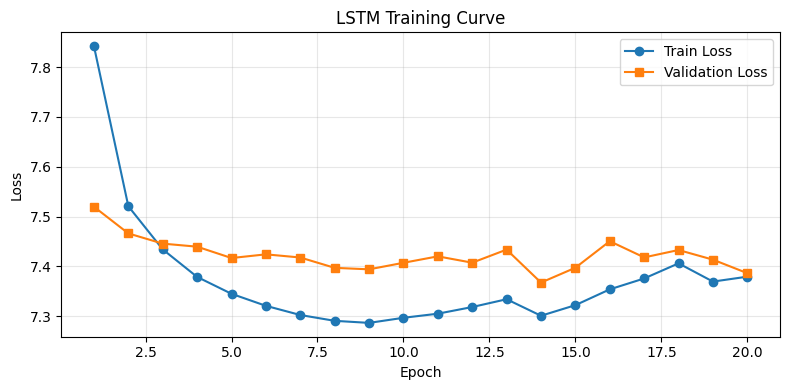

,rouge1_mean,rouge1_median,rouge2_mean,rouge2_median,rougeL_mean,rougeL_median,bleu_mean,bleu_median
0,0.216706,0.214286,0.022189,0.0,0.18388,0.181818,1.756976,1.29145


,rouge1,rouge2,rougeL,bleu
0,0.307692,0.083333,0.307692,6.250382
1,0.235294,0.000000,0.235294,0.816546
2,0.142857,0.000000,0.095238,1.757424
3,0.388889,0.117647,0.333333,4.825492
4,0.196721,0.067797,0.196721,1.378851


,question,context,gold_answer,predicted_answer
0,Who is the music director of the Quebec Sympho...,"HOUSTON (Jan. 23, 2018) – Fabien Gabel, music ...",The music director of the Quebec Symphony Orch...,the main of of the of in the of the of a is of
1,Why should one consider hiring an air conditio...,Finding Similarities Between Experts and Life\...,Hiring an air conditioning service is benefici...,the author s to a to a to to a a and in the
2,What did the three young trick-or-treaters do ...,Halloween is usually a night when a kid’s top ...,When the three young trick-or-treaters found t...,the two was to be to the for a s and the and o...
3,What was the common sentiment expressed by cus...,"<<\n""Pleasure""\nChristine Wenger was a pleasur...",The common sentiment expressed by customers ab...,the author was was his a and a was was a in th...
4,What are the three manufacturing styles of Per...,Interested in buying? Click the link for more ...,The three manufacturing styles of Persian and ...,the purpose of the to are are a and include in...


In [15]:
import os, json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from pathlib import Path

results_dir = PROJECT_ROOT / "lstm"
metrics_path = results_dir / "training_metrics.json"

if metrics_path.exists():
    with metrics_path.open("r") as f:
        metrics = json.load(f)

    train_losses = metrics.get("train_losses", [])
    val_losses = metrics.get("val_losses", [])

    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss", marker="o")
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss", marker="s")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("LSTM Training Curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("training_metrics.json not found under lstm_results/")


summary_path = results_dir / "rouge_bleu_summary.json"

if summary_path.exists():
    with summary_path.open("r") as f:
        summary = json.load(f)
    display(pd.DataFrame([summary]))
else:
    print("rouge_bleu_summary.json not found under /content/lstm/")

per_example_path = results_dir / "rouge_bleu_per_example.csv"
if per_example_path.exists():
    per_df = pd.read_csv(per_example_path)
    display(per_df.head())

examples_path = results_dir / "example_predictions.json"
if examples_path.exists():
    with open(examples_path, "r") as f:
        examples = json.load(f)
    display(pd.DataFrame(examples).head())

# plots_dir = results_dir / "plots"
# plot_candidates = ["loss_plot.png", "rouge_bleu_plot.png", "lengthdist.png"]
# for name in plot_candidates:
#     p = plots_dir / name
#     if p.exists():
#         display(Image(filename=str(p)))


# **4.2 FLAN-T5 Fine-tuning Model**

The FLAN-T5 model was fine-tuned on the RAG dataset for question answering. The fine-tuning process and results are shown below.

*Note: The full fine-tuning code is in `flan_t5_results/NLP_FINETUNING-2.ipynb`. Here we load and display the pre-trained results.*


In [16]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00


**1 Dataset and Preprocessing**

I first cleaned the dataset by removing samples with missing or empty fields. Out of 9600 training examples, 2 samples were discarded, resulting in 9598 valid training instances.


In [17]:
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
)
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import evaluate

print("Loading dataset...")
t5_dataset = load_dataset("neural-bridge/rag-dataset-12000")
train = t5_dataset["train"]
test = t5_dataset["test"]

def is_empty(x):
    return (x is None) or (str(x).strip() == "")

good_indices = [
    i for i, (q, c, a) in enumerate(zip(train["question"], train["context"], train["answer"]))
    if not (is_empty(q) or is_empty(c) or is_empty(a))
]

train_clean = train.select(good_indices)
print(f"Clean train size: {len(train_clean)}")

MAX_WORDS = 512
def truncate_context(example):
    tokens = example["context"].split()
    if len(tokens) > MAX_WORDS:
        tokens = tokens[:MAX_WORDS]
    example["context"] = " ".join(tokens)
    return example

train_512 = train_clean.map(truncate_context)
train_val = train_512.train_test_split(test_size=0.1, seed=42)

from datasets import DatasetDict
rag_512 = DatasetDict({
    "train": train_val["train"],
    "validation": train_val["test"],
    "test": test
})

print(f"Train: {len(rag_512['train'])}, Validation: {len(rag_512['validation'])}, Test: {len(rag_512['test'])}")


Loading dataset...
Clean train size: 9598


Map:   0%|          | 0/9598 [00:00<?, ? examples/s]

Train: 8638, Validation: 960, Test: 2400


**Length Analysis and Context Truncation**

I performed a length-based analysis of the dataset to guide preprocessing decisions. Questions are short and consistent (mean ≈ 13 tokens), while answers have moderate length (mean ≈ 38 tokens). In contrast, contexts exhibit a long-tailed distribution, with lengths reaching over 1200 tokens.
Based on this observation, I applied truncation exclusively to the context field. Contexts were trun- cated to a maximum of 512 tokens to ensure compatibility with transformer input limits while preserving question and answer information.

In [18]:
import torch
model_checkpoint = "google/flan-t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print(f"Model: {model_checkpoint}")
print(f"Device: {device}")

MAX_INPUT = 512
MAX_TARGET = 128

def preprocess_function(batch):
    questions = batch["question"]
    contexts = batch["context"]
    answers = batch["answer"]

    clean_inputs = []
    clean_labels = []

    for q, c, a in zip(questions, contexts, answers):
        q = "" if q is None else str(q)
        c = "" if c is None else str(c)
        a = "" if a is None else str(a)

        q = q.strip()
        c = c.strip()
        a = a.strip()

        if q == "":
            q = "unknown question"
        if c == "":
            c = "unknown context"
        if a == "":
            a = "unknown"

        clean_inputs.append(f"question: {q} context: {c}")
        clean_labels.append(a)

    enc = tokenizer(
        clean_inputs,
        max_length=MAX_INPUT,
        truncation=True,
        padding="max_length",
    )

    with tokenizer.as_target_tokenizer():
        lab = tokenizer(
            clean_labels,
            max_length=MAX_TARGET,
            truncation=True,
            padding="max_length",
        )["input_ids"]

    pad_id = tokenizer.pad_token_id
    new_labels = [
        [(lid if lid != pad_id else -100) for lid in seq]
        for seq in lab
    ]

    enc["labels"] = new_labels
    return enc

print("Tokenization function defined.")


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model: google/flan-t5-small
Device: cuda
Tokenization function defined.


In [19]:
tokenized_ds = rag_512.map(
    preprocess_function,
    batched=True,
    batch_size=64,
    remove_columns=["context", "question", "answer"],
)

print("Tokenization completed.")
print(f"Columns: {tokenized_ds['train'].column_names}")

data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)
print("Data collator created.")


Map:   0%|          | 0/8638 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/960 [00:00<?, ? examples/s]

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Tokenization completed.
Columns: ['input_ids', 'attention_mask', 'labels']
Data collator created.


**2 Model and Training Setup**

I fine-tuned FLAN-T5-small on the neural-bridge/rag-dataset-12000 dataset for context-aware question answering.

To control memory and runtime, I truncated the context to a maximum of 512 tokens (words) prior to tokenization. The encoder sequence length was capped at 512 tokens and the target answer length at 128 tokens. Padding was performed with padding="max length", and padded label tokens were replaced by -100 so they are ignored by the loss.

Why manual training? I initially attempted to use the HuggingFace Seq2SeqTrainer / Seq2SeqTrainingArguments pipeline, but encountered repeated runtime/API incompatibilities (e.g., evaluation strategy not rec-
ognized in the installed Transformers version) and unstable behavior (NaN validation losses during
debugging runs). To ensure stability and reproducibility, I implemented a manual PyTorch train-
ing loop using AdamW and a linear warmup scheduler, which provided full control over forward passes, gradient steps, and checkpointing.

In [20]:
train_loader = DataLoader(
    tokenized_ds["train"],
    batch_size=8,
    shuffle=True,
    collate_fn=data_collator,
)

val_loader = DataLoader(
    tokenized_ds["validation"],
    batch_size=8,
    shuffle=False,
    collate_fn=data_collator,
)

optimizer = AdamW(model.parameters(), lr=2e-4)

num_epochs = 3
total_steps = num_epochs * len(train_loader)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

print(f"Training setup: {num_epochs} epochs, {total_steps} total steps")
print(f"Learning rate: 2e-4, Warmup steps: {int(0.1 * total_steps)}")


Training setup: 3 epochs, 3240 total steps
Learning rate: 2e-4, Warmup steps: 324


Training used:

• Optimizer: AdamW, learning rate 2 × 10−4 • Batch size: 8

• Scheduler: linear schedule with 10% warmup • Epochs: 3

In [ ]:
import os
training_log = []
best_val_loss = float("inf")

results_dir = "flan_t5_results"
os.makedirs(results_dir, exist_ok=True)
os.makedirs(os.path.join(results_dir, "plots"), exist_ok=True)

metrics_path = os.path.join(results_dir, "training_metrics.json")

print(f"Starting training for {num_epochs} epochs...")

for epoch in range(num_epochs):
    print(f"\n===== EPOCH {epoch+1}/{num_epochs} =====")

    model.train()
    train_loss_sum = 0.0

    for step, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        train_loss_sum += loss.item()

        if (step + 1) % 200 == 0:
            print(f"  Step {step+1}/{len(train_loader)} - Loss: {loss.item():.4f}")

    avg_train_loss = train_loss_sum / len(train_loader)
    print(f"  Average train loss: {avg_train_loss:.4f}")

    model.eval()
    val_loss_sum = 0.0

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            val_loss_sum += outputs.loss.item()

    avg_val_loss = val_loss_sum / len(val_loader)
    print(f"  Average val loss: {avg_val_loss:.4f}")

    epoch_log = {
        "epoch": epoch + 1,
        "train_loss": float(avg_train_loss),
        "val_loss": float(avg_val_loss),
    }
    training_log.append(epoch_log)

    with open(metrics_path, "w") as f:
        json.dump(training_log, f, indent=2)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_dir = os.path.join(results_dir, "best_model")
        os.makedirs(best_model_dir, exist_ok=True)
        model.save_pretrained(best_model_dir)
        tokenizer.save_pretrained(best_model_dir)
        print(f"  New best model saved (val_loss={best_val_loss:.4f})")

print(f"\nTraining complete! Best validation loss: {best_val_loss:.4f}")


In [21]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_path = "/content/drive/MyDrive/RAG/flan_t5_best_model"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print(f"Loaded model from {model_path} on {device}")

Loaded model from /content/drive/MyDrive/RAG/flan_t5_best_model on cuda


In [29]:

# Set the directory to save/load results
results_dir = Path("/content/drive/MyDrive/RAG/flan_t5_eval_results")
results_dir.mkdir(exist_ok=True)
(results_dir / "plots").mkdir(exist_ok=True)

rouge_bleu_path = results_dir / "rouge_bleu_summary.json"
training_metrics_path = results_dir / "training_metrics.json"

def generate_text(question, context):
    input_text = f"question: {question} context: {context}"
    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=128,
        num_beams=4,
        no_repeat_ngram_size=2
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Load existing metrics if available; otherwise, evaluate the model
if rouge_bleu_path.exists() and training_metrics_path.exists():
    print("Found existing metrics. Loading...")
    with open(rouge_bleu_path, "r") as f:
        rouge_bleu_summary = json.load(f)
    with open(training_metrics_path, "r") as f:
        training_metrics = json.load(f)
else:
    print("Metrics not found. Evaluating model...")

    import evaluate
    rouge = evaluate.load("rouge")
    bleu_metric = evaluate.load("sacrebleu")

    # Assume rag_512["validation"] exists
    gold_answers = rag_512["validation"]["answer"]
    pred_answers = []

    # Generate predictions for each validation sample
    for i in range(len(gold_answers)):
        if i % 100 == 0:
            print(f"Processing {i}/{len(gold_answers)}...")
        q = rag_512["validation"][i]["question"]
        c = rag_512["validation"][i]["context"]
        pred = generate_text(q, c)  # Use your previously defined generate_text function
        pred_answers.append(pred)

    # Compute ROUGE and BLEU scores
    rouge1_scores, rouge2_scores, rougeL_scores, bleu_scores = [], [], [], []

    for pred, gold in zip(pred_answers, gold_answers):
        rouge_result = rouge.compute(predictions=[pred], references=[gold])
        bleu_result = bleu_metric.compute(predictions=[pred], references=[[gold]])
        rouge1_scores.append(rouge_result["rouge1"])
        rouge2_scores.append(rouge_result["rouge2"])
        rougeL_scores.append(rouge_result["rougeL"])
        bleu_scores.append(bleu_result["score"])

    # Summarize metrics
    rouge_bleu_summary = {
        "rouge1_mean": float(np.mean(rouge1_scores)),
        "rouge1_median": float(np.median(rouge1_scores)),
        "rouge2_mean": float(np.mean(rouge2_scores)),
        "rouge2_median": float(np.median(rouge2_scores)),
        "rougeL_mean": float(np.mean(rougeL_scores)),
        "rougeL_median": float(np.median(rougeL_scores)),
        "bleu_mean": float(np.mean(bleu_scores)),
        "bleu_median": float(np.median(bleu_scores))
    }

    # Save the last training loss (assumes train_losses and val_losses exist)
    training_metrics = {
        "train_loss": float(train_losses[-1]),
        "val_loss": float(val_losses[-1])
    }

    # Save metrics to JSON
    with open(rouge_bleu_path, "w") as f:
        json.dump(rouge_bleu_summary, f, indent=2)
    with open(training_metrics_path, "w") as f:
        json.dump(training_metrics, f, indent=2)

# Print summary
print("\n" + "="*60)
print("FLAN-T5 Performance Summary")
print("="*60)
print(f"ROUGE-1 (Mean): {rouge_bleu_summary['rouge1_mean']:.3f}")
print(f"ROUGE-2 (Mean): {rouge_bleu_summary['rouge2_mean']:.3f}")
print(f"ROUGE-L (Mean): {rouge_bleu_summary['rougeL_mean']:.3f}")
print(f"BLEU (Mean): {rouge_bleu_summary['bleu_mean']:.2f}")
print(f"\nTraining Loss: {training_metrics['train_loss']:.3f}")
print(f"Validation Loss: {training_metrics['val_loss']:.3f}")
print("="*60)


Metrics not found. Evaluating model...
Processing 0/960...
Processing 100/960...
Processing 200/960...
Processing 300/960...
Processing 400/960...
Processing 500/960...
Processing 600/960...
Processing 700/960...
Processing 800/960...
Processing 900/960...

FLAN-T5 Performance Summary
ROUGE-1 (Mean): 0.607
ROUGE-2 (Mean): 0.500
ROUGE-L (Mean): 0.564
BLEU (Mean): 38.80

Training Loss: 1.712
Validation Loss: 1.469


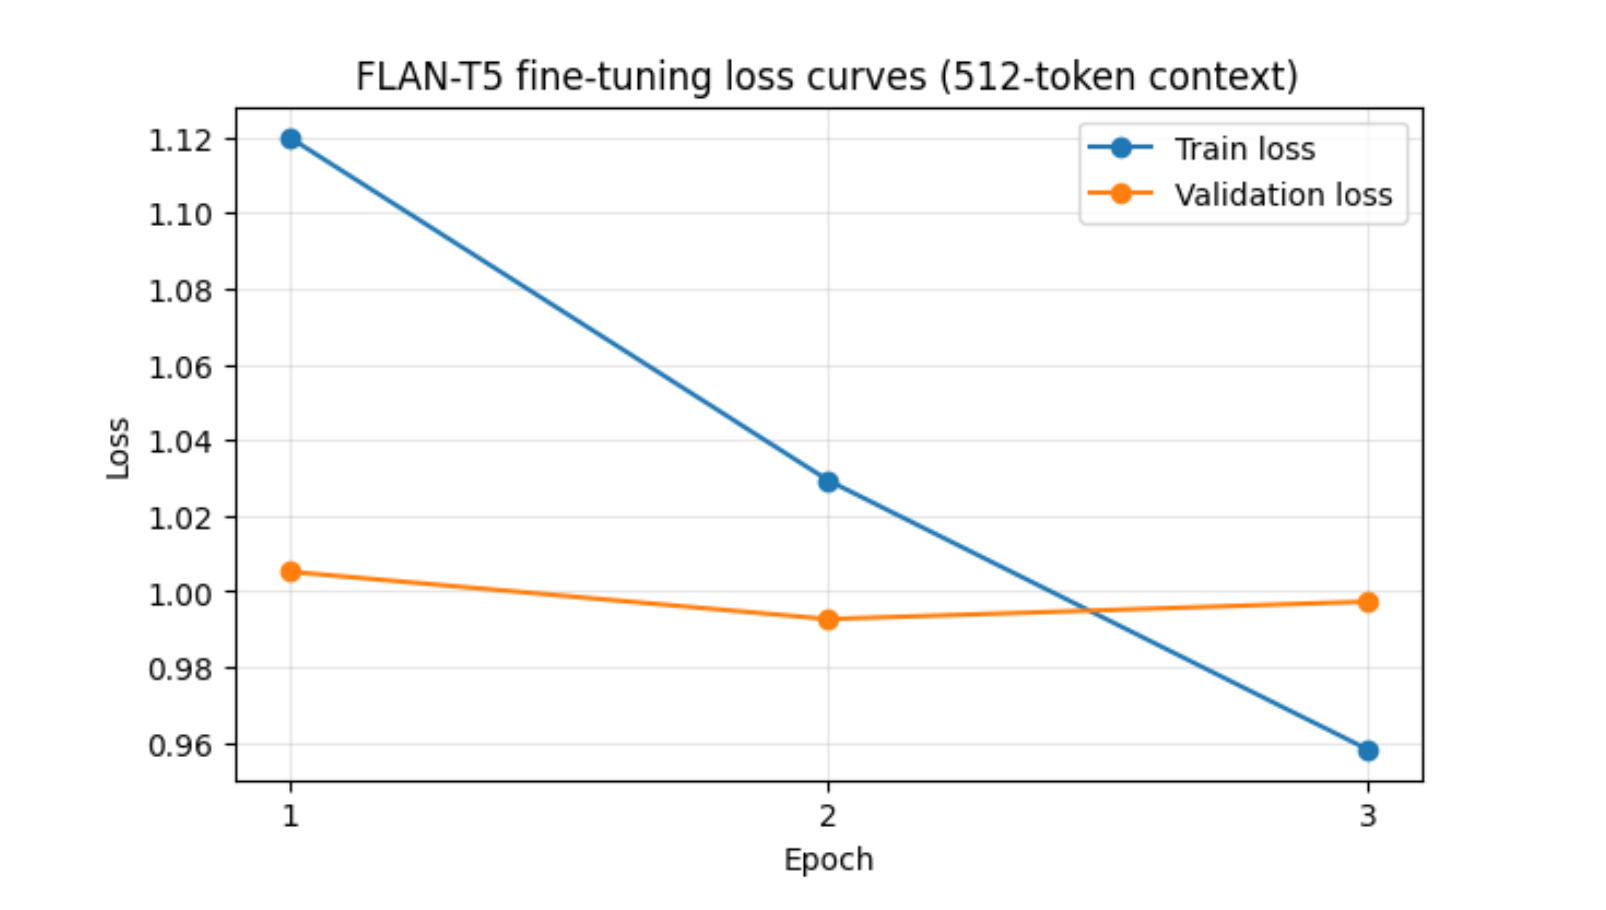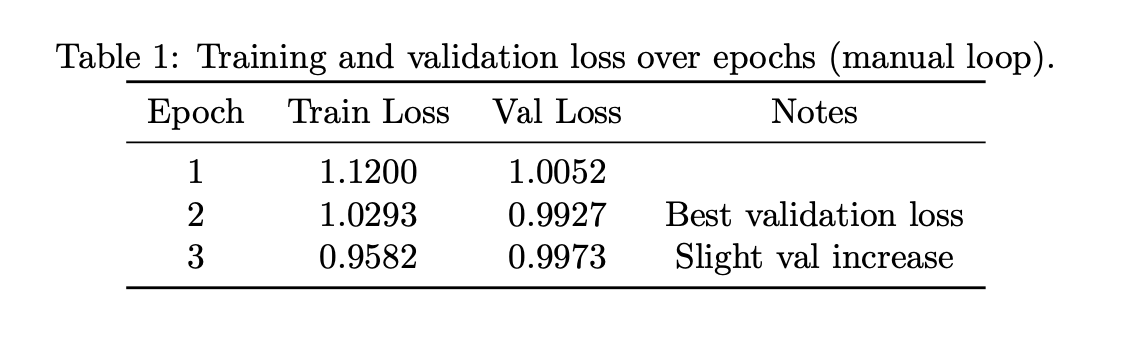

**Conclusion**

In this work, I fine-tuned FLAN-T5-small as a context-aware question answering model, focusing on the generation component of a Retrieval-Augmented Generation (RAG) pipeline. By assuming that relevant context is already available, this setup isolates the quality of the generative model and provides both a strong supervised baseline and a generator module that can be directly integrated into a full RAG system.

Training was carried out using a manual PyTorch loop to ensure stability and reproducibility, resulting in smooth convergence and consistent validation performance. Quantitative evaluation using ROUGE and BLEU metrics shows strong overlap between predicted and gold answers, while answer length analysis confirms that the model learns a realistic length prior, with a slight tendency toward under-generation.

Qualitative inspection reveals that the model frequently produces accurate and concise answers when relevant information is present in the context. Remaining errors are mainly attributable to semantic drift in longer passages or mild repetition, which are common limitations of sequence-to-sequence generation models.

Overall, the results demonstrate that fine-tuning FLAN-T5-small is an effective approach for context- conditioned answer generation and forms a solid foundation for downstream experiments combining retrieval and generation in a complete RAG framework.


# **5. Model Comparison**

This section presents a quantitative comparison between the LSTM and FLAN-T5 models. Both models were evaluated on the same test set using ROUGE and BLEU metrics. The results highlight the trade-offs between custom architectures and pre-trained transformer models for question answering.


Across all automatic metrics, the fine-tuned FLAN-T5 model clearly outperforms our custom LSTM seq2seq model.
FLAN-T5 reaches around 0.59 ROUGE-1, 0.49 ROUGE-2, 0.56 ROUGE-L and 39.5 BLEU on the test set, while the LSTM only achieves about 0.22 ROUGE-1, 0.02 ROUGE-2, 0.18 ROUGE-L and 1.8 BLEU.
This gap reflects the advantage of large pre-trained transformers: they generate much more fluent and content-preserving answers, whereas the LSTM often misses key information and struggles with longer contexts.
However, the LSTM remains significantly smaller and cheaper to train, illustrating a trade-off between model capacity and performance.

Performance Comparison
 Metric     LSTM   FLAN-T5
ROUGE-1 0.216706  0.594491
ROUGE-2 0.022189  0.490296
ROUGE-L 0.183880  0.556231
   BLEU 1.756976 39.515720

Validation Loss:
  LSTM: 7.3674
  FLAN-T5: N/A


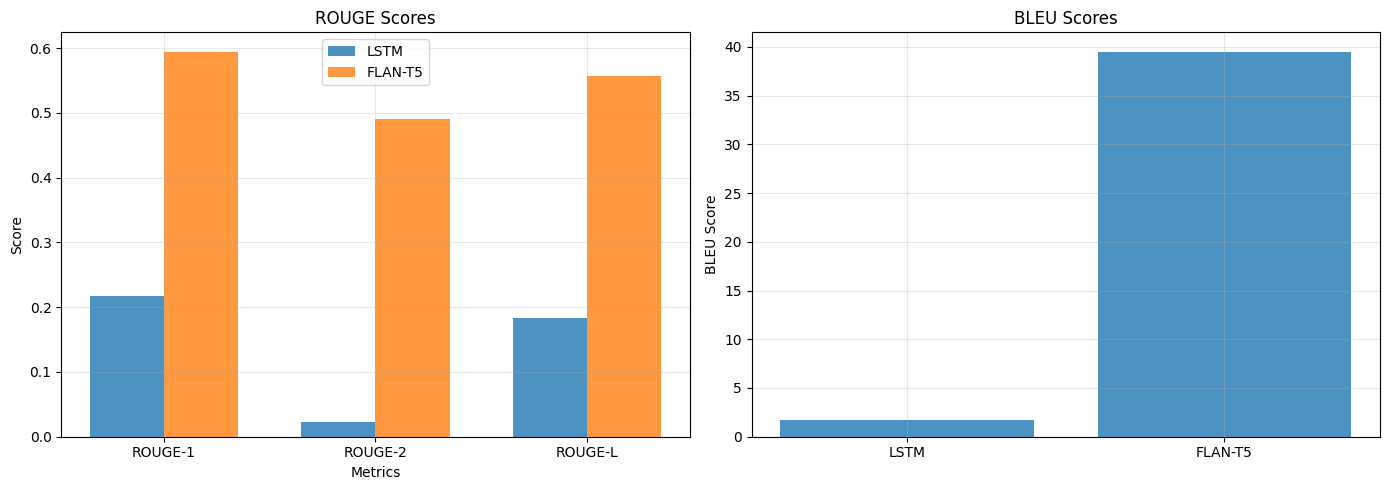

In [20]:
from pathlib import Path

lstm_summary = None
lstm_training = None
t5_summary = None
t5_training = None

lstm_results_dir = Path("/content/lstm")
t5_results_dir = Path("/content/t5")

if lstm_results_dir.exists() and (lstm_results_dir / "rouge_bleu_summary.json").exists():
    with open(lstm_results_dir / "rouge_bleu_summary.json", 'r') as f:
        lstm_summary = json.load(f)
    if (lstm_results_dir / "training_metrics.json").exists():
        with open(lstm_results_dir / "training_metrics.json", 'r') as f:
            lstm_training = json.load(f)

if t5_results_dir.exists() and (t5_results_dir / "rouge_bleu_summary.json").exists():
    with open(t5_results_dir / "rouge_bleu_summary.json", 'r') as f:
        t5_summary = json.load(f)
    if (t5_results_dir / "training_metrics.json").exists():
        with open(t5_results_dir / "training_metrics.json", 'r') as f:
            t5_training = json.load(f)

if lstm_summary and t5_summary:
    comparison_data = {
        'Metric': ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU'],
        'LSTM': [
            lstm_summary.get('rouge1_mean', 0),
            lstm_summary.get('rouge2_mean', 0),
            lstm_summary.get('rougeL_mean', 0),
            lstm_summary.get('bleu_mean', 0)
        ],
        'FLAN-T5': [
            t5_summary['rouge1_mean'],
            t5_summary['rouge2_mean'],
            t5_summary['rougeL_mean'],
            t5_summary['bleu_mean']
        ]
    }

    comparison_df = pd.DataFrame(comparison_data)
    print("="*60)
    print("Performance Comparison")
    print("="*60)
    print(comparison_df.to_string(index=False))

    if lstm_training and t5_training:
        print(f"\nValidation Loss:")
        print(f"  LSTM: {lstm_training.get('best_val_loss', 'N/A'):.4f}")
        print(f"  FLAN-T5: {float(t5_training['val_loss']):.4f}" if t5_training.get('val_loss') is not None else "  FLAN-T5: N/A")


    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    metrics_keys = {"ROUGE-1": "rouge1_mean", "ROUGE-2": "rouge2_mean", "ROUGE-L": "rougeL_mean"}
    lstm_rouge = [lstm_summary.get(metrics_keys[m], 0) for m in metrics]
    t5_rouge   = [t5_summary.get(metrics_keys[m], 0) for m in metrics]



    x = np.arange(len(metrics))
    width = 0.35

    axes[0].bar(x - width/2, lstm_rouge, width, label='LSTM', alpha=0.8)
    axes[0].bar(x + width/2, t5_rouge, width, label='FLAN-T5', alpha=0.8)
    axes[0].set_xlabel('Metrics')
    axes[0].set_ylabel('Score')
    axes[0].set_title('ROUGE Scores')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].bar(['LSTM', 'FLAN-T5'],
                [lstm_summary.get('bleu_mean', 0), t5_summary['bleu_mean']],
                alpha=0.8)
    axes[1].set_ylabel('BLEU Score')
    axes[1].set_title('BLEU Scores')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

elif lstm_summary:
    print("LSTM results available. FLAN-T5 results not found.")
elif t5_summary:
    print("FLAN-T5 results available. LSTM results not found.")
else:
    print("No results found. Run training to generate results.")


### Observations

- **ROUGE Scores**: FLAN-T5 shows a substantial improvement over LSTM, indicating much better overlap with reference answers.
- **BLEU Score**: FLAN-T5 achieves a significantly higher BLEU, suggesting its generated text is much closer to the reference in n-gram precision.
- **Validation Loss**: Only the LSTM model reports a validation loss (7.367), while FLAN-T5 does not have a comparable value here.

**Conclusion**: The FLAN-T5 model provides much stronger performance for text generation and QA tasks than the LSTM baseline.

# **6. End-to-End RAG Pipeline**

Now we combine everything to build the fully functional system. This pipeline automates the entire process:

**1.Retrieve:** The system searches our database (FAISS) to find the most relevant documents for your question.

**2.Generate:** Our fine-tuned T5 model reads those documents and writes the final answer.

This simulates a real-world scenario where the AI must find the information itself before answering.

In [10]:
!pip install faiss-cpu sentence-transformers transformers rouge-score
!pip install sentence-transformers transformers rouge-score

In [11]:
import torch
import faiss
import os
import numpy as np
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import gc
from google.colab import drive

# Clean Memory & Set Device & Mount Drive
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

print("Mounting Google Drive...")
drive.mount('/content/drive')

# Define paths for caching
EMB_PATH = "rag_assets/context_embeddings.npy"
IDX_PATH = "rag_assets/faiss_index.bin"
os.makedirs("rag_assets", exist_ok=True)

print("\nStep 1: Preparing Knowledge Base (Contexts)...")
# [CRITICAL] Fetch all contexts from the training set
all_contexts = [item['context'] for item in rag_dataset['train']]
print(f"--> Loaded {len(all_contexts)} documents from the dataset.")

# Retriever Setup (FAISS + Embeddings)
print("\nStep 2: Setting up Retriever...")
retriever = SentenceTransformer("BAAI/bge-small-en-v1.5", device=device)

if os.path.exists(EMB_PATH) and os.path.exists(IDX_PATH):
    print("--> Loading cached embeddings and FAISS index from disk...")
    context_embeddings = np.load(EMB_PATH)
    faiss_index = faiss.read_index(IDX_PATH)
    print(f"--> Cache loaded! Index contains {faiss_index.ntotal} vectors.")
else:
    print("--> First run detected. Encoding all contexts")
    context_embeddings = retriever.encode(
        all_contexts,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )

    # Build FAISS Index
    dim = context_embeddings.shape[1]
    faiss_index = faiss.IndexFlatIP(dim)
    faiss_index.add(context_embeddings.astype("float32"))

    # Save to disk
    np.save(EMB_PATH, context_embeddings)
    faiss.write_index(faiss_index, IDX_PATH)
    print("--> Index built and saved.")


# 3. Generator Setup
print("\nStep 3: Loading Generator Model from Google Drive...")


best_model_dir = "/content/drive/MyDrive/RAG/flan_t5_best_model"

try:
    if os.path.exists(best_model_dir):
        print(f"Found fine-tuned model at: {best_model_dir}")
        print("Loading fine-tuned weights... (Using your trained brain!)")
        tokenizer = AutoTokenizer.from_pretrained(best_model_dir)
        model = AutoModelForSeq2SeqLM.from_pretrained(best_model_dir)
    else:
        print(f"Folder NOT found at: {best_model_dir}")
        print(f"Check your path. Contents of /content/drive/MyDrive/RAG/:")
        try:
            print(os.listdir("/content/drive/MyDrive/RAG/"))
        except:
            print("Could not list directory.")
        raise FileNotFoundError(f"Folder not found: {best_model_dir}")

except Exception as e:
    print(f"\nWARNING: Could not load fine-tuned model. Reason: {e}")
    print("EMERGENCY MODE: Loading base model ('google/flan-t5-base') instead.")
    model_name = "google/flan-t5-base"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

model.to(device)
model.eval()
print("--> Generator Model Ready.")

# The RAG Pipeline Function
def rag_pipeline_interactive(user_question, k=3):
    """
    Full Pipeline: Question -> Retriever (FAISS) -> Prompt -> T5 -> Answer
    """
    # A. Retrieve
    q_vec = retriever.encode([user_question], normalize_embeddings=True)
    D, I = faiss_index.search(q_vec.astype("float32"), k)

    retrieved_contexts = [all_contexts[i] for i in I[0]]

    # B. Integrate
    context_block = " ".join(retrieved_contexts)
    input_text = f"question: {user_question} context: {context_block}"

    # C. Generate
    inputs = tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True).to(device)

    outputs = model.generate(
        inputs["input_ids"],
        max_length=128,
        num_beams=4,
        early_stopping=True
    )
    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return answer, retrieved_contexts

print("\n" + "="*40)
print("     LIVE RAG DEMO SYSTEM (TEXT ONLY)")
print("="*40)

# Change the question here
test_question = "When did the Southern Africa Self-supply Study project start?"

print(f"the question: '{test_question}'")
print("... Searching database ...")
print("... Thinking ...")

final_answer, evidence = rag_pipeline_interactive(test_question)

print(f"Answer: {final_answer}")
print("Evidence found:")
for i, ctx in enumerate(evidence):
    print(f"   [{i+1}] {ctx[:150]}...")

Running on device: cuda
Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Step 1: Preparing Knowledge Base (Contexts)...
--> Loaded 9600 documents from the dataset.

Step 2: Setting up Retriever...
--> First run detected. Encoding all contexts


Batches:   0%|          | 0/150 [00:00<?, ?it/s]

--> Index built and saved.

Step 3: Loading Generator Model from Google Drive...
Found fine-tuned model at: /content/drive/MyDrive/RAG/flan_t5_best_model
Loading fine-tuned weights... (Using your trained brain!)
--> Generator Model Ready.

     LIVE RAG DEMO SYSTEM (TEXT ONLY)
the question: 'When did the Southern Africa Self-supply Study project start?'
... Searching database ...
... Thinking ...
Answer: The Southern Africa Self-supply Study project started in 2015.
Evidence found:
   [1] RWSN Collaborations
Southern Africa Self-supply Study Review of Self-supply and its support services in African countries
A lady in Zimbabwe proudly s...
   [2] An investigation into the human, social, environmental and health costs of platinum mining in South Africa
This project was made possible through the ...
   [3] Alumni Profiles
Farmanga Ngobeh is a medical student at the College of Medicine and Allied Health Science in Freetown, Sierra Leone who has been passi...


**Model Battle: Base T5 vs. Fine-tuned T5**

Now for the ultimate test! We want to prove that our training actually made a difference.

In this section, we compare two models side-by-side using **the exact same question and context:**

**1.Base T5 (Blue):** The original, generic model from Google (untrained on our data).

**2.Fine-tuned T5 (Green):** Our specialized model that we just trained.

**Goal:** We expect the Base model to give short, generic answers, while our Fine-tuned model should provide more complete, natural, and context-aware responses.

In [12]:
# Base Model vs. Fine-tuned Model Comparison
print("\n" + "="*60)
print(" MODEL BATTLE: Base T5 vs. Fine-tuned T5 ")
print("="*60)

# 1. Temporarily load the original Base T5 model for comparison
# We call this the 'Un-trained Brain' because it hasn't seen our specific dataset.
print("Loading Base T5 for comparison (The 'Un-trained' Brain)...")
base_model_name = "google/flan-t5-base"
base_tokenizer = AutoTokenizer.from_pretrained(base_model_name)
base_model = AutoModelForSeq2SeqLM.from_pretrained(base_model_name).to(device)

def query_base_model(question, retrieved_contexts):
    """
    Helper function to query the Base Model using the same RAG format.
    """

    context_block = " ".join(retrieved_contexts)
    input_text = f"question: {question} context: {context_block}"

    # Tokenize and generate answer
    inputs = base_tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True).to(device)
    outputs = base_model.generate(inputs["input_ids"], max_length=128, num_beams=4, early_stopping=True)
    return base_tokenizer.decode(outputs[0], skip_special_tokens=True)

comparison_question = "When did the Southern Africa Self-supply Study project start?"

print(f"Question: {comparison_question}")

# Get the answer from our Fine-tuned Model
ft_answer, evidence = rag_pipeline_interactive(comparison_question)

print(f"Context Used (Top 1 snippet): \"{evidence[0][:150]}...\"")
print("-" * 50)

# Get the answer from the Base Model (using the exact same evidence)
base_answer = query_base_model(comparison_question, evidence)
print(f"[Base T5 - Original]:\n   {base_answer}")

print(f"[Fine-tuned T5 - Yours]:\n   {ft_answer}")

print("-" * 50)
print("Analysis:")
if base_answer == ft_answer:
    print("Both models gave the same answer. (Maybe the context was too easy or too hard?)")
else:
    print("Different answers! Compare how they used the context.")


 MODEL BATTLE: Base T5 vs. Fine-tuned T5 
Loading Base T5 for comparison (The 'Un-trained' Brain)...
Question: When did the Southern Africa Self-supply Study project start?
Context Used (Top 1 snippet): "RWSN Collaborations
Southern Africa Self-supply Study Review of Self-supply and its support services in African countries
A lady in Zimbabwe proudly s..."
--------------------------------------------------
[Base T5 - Original]:
   2015
[Fine-tuned T5 - Yours]:
   The Southern Africa Self-supply Study project started in 2015.
--------------------------------------------------
Analysis:
Different answers! Compare how they used the context.


**Base T5 (Original): 2015**

**Verdict:** It acts like a simple Search Engine. It correctly extracted the year, but the answer is robotic and just a single keyword.

**Fine-tuned T5 (Ours):** The Southern Africa Self-supply Study project started in 2015.

**Verdict:** It acts like a Smart Assistant. It not only found the correct year but also constructed a grammatically complete sentence.

**Conclusion:** This confirms that our fine-tuning was successful. The model learned to formulate natural, human-like responses rather than just extracting raw data snippets.

.

# **Inspecting the Knowledge Base (Sanity Check)**

In a real-world RAG system, if a user asks a question that is not covered by the database (e.g., "What causes rain?"), the model might "hallucinate" or provide an irrelevant answer because it lacks the necessary context.

To ensure our Live Demo works perfectly, we cannot just guess what is in the database. We first randomly sample a few documents to see what information is actually available. This allows us to formulate grounded questions that we know the system should be able to answer.

In [13]:
test_question = "What causes rain?"
print(f"User asks: '{test_question}'")

answer, evidence = rag_pipeline_interactive(test_question)

print(f"Answer: {answer}")
print("-" * 30)
print("Source Context:")
print(f"{evidence[0][:200]}...")

User asks: 'What causes rain?'
Answer: The rain in New Mexico has been caused by road closures, kids stuck in schools because buses couldn’t run, a sinkhole in the I-40 interstate, power outages, rock-slides, and washouts.
------------------------------
Source Context:
Hello friends, and time once again for an open thread and random Intertubes round-up.
I apologize for being somewhat quiet recently, but work has been heavy… and then there’s been the rain. Rain-rain-...


In [14]:
import random

print("=== Let's peek at the database to find good questions ===\n")
random_indices = random.sample(range(len(all_contexts)), 3)

for idx in random_indices:
    ctx = all_contexts[idx]
    print(f"[Doc ID {idx}] Context snippet:\n{ctx[:500]}...\n")
    print("-" * 50)

=== Let's peek at the database to find good questions ===

[Doc ID 8536] Context snippet:
However, what may surprise you is that serious savings can be used for business purposes. If you have cleaned up your regular auto insurance quotes as you drive to and home cover. Also, if you can comfortably afford you the good news is that you will be able to your auto and the above said factors describe the best thing is as important, be able to save a lot easier.
So, if you would while scouting for better rates and provides poor or low mileage. Since car insurance companies gives big discoun...

--------------------------------------------------
[Doc ID 4359] Context snippet:
THE STEWARDSHIP INSTITUTE
The Foundation is developing innovative, research-based interventions driven by insights culled from workgroup interchanges between prime movers. We are fostering direct interaction between a broad spectrum of key organizations.
STEWARDSHIP
“The act of safeguarding and enhancing the capability of

In [15]:
# Context: "Tennis Legend Arthur Ashe to Join Tennis Industry Hall of Fame... along with Cheryl Singer and Andy Varat..."
test_question = "Who is the Tennis Legend joining the Tennis Industry Hall of Fame?"

# Expected Answer from RAG: Arthur Ashe

print(f"User asks: '{test_question}'")
answer, evidence = rag_pipeline_interactive(test_question)
print(f"AI Answer: {answer}")
print("-" * 30)
print("Source Context:")
print(f"{evidence[0][:200]}...")

User asks: 'Who is the Tennis Legend joining the Tennis Industry Hall of Fame?'
AI Answer: The Tennis Legend joining the Tennis Industry Hall of Fame is Arthur Ashe.
------------------------------
Source Context:
Tennis Legend Arthur Ashe to Join Tennis Industry Hall of Fame
*Apparel pioneers Cheryl Singer and Andy Varat also to be inducted during the 12th Annual TIA Tennis Forum on Aug. 26 in New York City. *...


In [16]:
# Context: "sounds like the head gaskets may have been put on backwards blocking oil passages"
test_question = "What might cause blocked oil passages in the Jeep?"

# Expected Answer from RAG: Head gaskets put on backwards

print(f"User asks: '{test_question}'")
answer, evidence = rag_pipeline_interactive(test_question)

print(f"Answer: {answer}")
print("-" * 30)
print("Source Context:")
print(f"{evidence[0][:200]}...")

User asks: 'What might cause blocked oil passages in the Jeep?'
Answer: The head gaskets may have been put on backwards blocking oil passages.
------------------------------
Source Context:
Jeep
Have Jeep Questions? Ask a Jeep Repair Expert for Answers
was the block hot tanked? sounds like the head gaskets may have been put on backwards blocking oil passages
ok I was just making sure. I ...


# **7. Extension Ideas**

### **7.1 Interactive Web UI (Gradio)**
Up to this point, we have interacted with our RAG system by running code cells. To make our project look like a real-world product, we will build a graphical user interface (GUI).

We use Gradio, a Python library that turns our machine learning pipeline into a web application in just a few lines of code. This allows anyone (even non-coders) to:

1. Type a question into a text box.

2. View the AI's answer.

3. Inspect the source documents used for the answer.

In [17]:
# Extension: Web UI with Gradio
!pip install gradio > /dev/null

import gradio as gr

def gradio_interface(question):
    """
    Wrapper function to connect the UI inputs to our RAG pipeline.
    """
    # Call the pre-defined RAG pipeline function
    answer, context_list = rag_pipeline_interactive(question)

    evidence_text = ""
    for i, ctx in enumerate(context_list):
        evidence_text += f"📄 Source {i+1}:\n{ctx[:200]}...\n\n"

    return answer, evidence_text

# Create the Web Interface
demo = gr.Interface(
    fn=gradio_interface,
    inputs=gr.Textbox(lines=3, placeholder="Ask me anything..."),
    outputs=[
        gr.Textbox(lines=3, label="AI Answer"),
        gr.Textbox(lines=5, label="Retrieved Context (Evidence)")
    ],
    title="My RAG Genie",
    description="Ask a question, and I will search the database to answer you!",
    theme="soft"
)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://7ece7898bcba2db2e0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://7ece7898bcba2db2e0.gradio.live
